## Fig 1-2: Comparison of CMIP6 and MITgcm (and observations)

This script reproduces Figs 1, 2, and S1-S4 of the Taylor et al. (Young Get Older, but Old Get Younger). This includes analysis of CMIP6 datasets, MITgcm Gradual-3.5C experiment, World Ocean Atlas O2, hydrographic data, and O2 observed compilations by Ito et al.  

In [50]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import xmitgcm as xm
import cmocean
import matplotlib.ticker as mticker

In [2]:
# CMIP6 age and O2 dataset processed by Busecke et al. 2022 (Pacific basin) 
# Need the link for this dataset; it must be somewhere.
CMIPdata = xr.open_dataset('/glade/work/bataylor/CMIP6_o2/data/full_3d_changes_combined.nc')


In [33]:
# Control and Gradual Warming run output

#fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
conTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-O2-Age-Tracers.nc'
conTr = xr.open_dataset(conTrnc)

conPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-Physical.nc'
conTS = xr.open_dataset(conPhnc)


O2con = xr.where(conTS.SALT==0, np.nan, conTr.Oxygen)
Agecon = xr.where(conTS.SALT==0, np.nan, conTr.Age)


#GrTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Gradual-3p5C-O2-Age-Tracers.nc'
GrTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Global-TransientFixed-3p5C-O2-Age-Tracers.nc'
GrTr = xr.open_dataset(GrTrnc)

O2Gr = xr.where(conTS.SALT==0, np.nan, GrTr.Oxygen)
AgeGr = xr.where(conTS.SALT==0, np.nan, GrTr.Age)

#GlTrnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Global-4C-O2-Age-Tracers.nc'
#GlTr = xr.open_dataset(GlTrnc)



#O2Gl = xr.where(conTS.SALT==0, np.nan, GlTr.Oxygen)
#AgeGl = xr.where(conTS.SALT==0, np.nan, GlTr.Age)



In [34]:


def calcTrend(da, namestr):
    # calculates linear trend over the timeseries for variable da
    
    # Convert time to numeric values 
    # unit is years, so this is not fully necessary. 
    time_num = np.array(da.time - da.time[0])  
    time_num = time_num.astype(float)
    
    # Get data as a numpy array
    #DIC50 = DIC50.transpose('XC', 'YC', 'Z', 'time') 
    data = da.values  # shape: (XC, YC, Z, time)
    
    # Reshape: flatten spatial dims to a single axis
    spatial_shape = data.shape[1:4]  
    n_spatial = np.prod(spatial_shape)
    n_time = data.shape[0]
    
    # Reshape for 2D regression: shape (n_spatial, time)
    data_2d = data.reshape(( n_time, n_spatial))
    
    # Remove NaNs
    #mask = ~np.any(np.isnan(data_2d), axis=1)
    valid_data = data_2d
    
    # Linear regression using np.polyfit (degree 1 gives slope + intercept)
    slopes = np.full(n_spatial, np.nan)
    for i in range(valid_data.shape[1]):
        slope, _ = np.polyfit(time_num, valid_data[:,i], deg=1)
        slopes[i] = slope
    
    # Reshape back to original spatial dimensions
    slopes_reshaped = slopes.reshape(spatial_shape)

    myxrda = xr.DataArray(
    slopes_reshaped*100, # Ok this gives the trend per century! 
    dims=('Z', 'YC', 'XC'),
    coords={k: da.coords[k] for k in ['Z', 'YC', 'XC']},
    name=namestr)

    return myxrda



In [35]:
# Apply trends for MITgcm runs. 
# units of result are mmol/m^3/Century

# control run trend
Agecontr = calcTrend(Agecon,'Age_tr100')
O2contr = calcTrend(O2con,'O2_tr100')
# trends in the gradual warming.
Agetr = calcTrend(AgeGr,'Age_tr100')
O2tr = calcTrend(O2Gr,'O2_tr100')



In [36]:
# Also we need nice values for the model control runs. Just mean whole 100-years.

O2conm =  O2con.mean('time')
Ageconm =  Agecon.mean('time')


In [7]:
WOAtest = xr.open_dataset('/glade/work/yeddebba/WOA/woa2023/woa23_all_o00_01.nc', decode_times=False)


# regridding WOA to the grid of the CMIP data. 
mask = WOAtest.o_an.isel(time=0) / WOAtest.o_an.isel(time=0)
lowlon = np.concatenate([np.arange(49.5,180.5),np.arange(-179.5, -50.5)]) 
highlon = np.concatenate([np.arange(50.5,180.5),np.arange(-179.5, -49.5)])


masklow = np.array(mask.sel(lon=lowlon))
maskhigh =np.array(mask.sel(lon=highlon))

o2low = np.array(WOAtest.o_an.sel(lon=lowlon).isel(time=0))
o2high= np.array(WOAtest.o_an.sel(lon=highlon).isel(time=0))

maskcomb = maskhigh + masklow # normalize by how many obs. 
# I should really just interpolate this, but this worked. 
o2comb = (o2high + o2low)/maskcomb

WOAnewz = np.zeros([75,120,260])
for x in range(260):
    for y in range(30,150):
        WOAnewz[:, y-30, x] =np.interp(CMIPdata.lev, WOAtest.depth, o2comb[:,y,x])

# just converting WOAnewz to xarray
mylat = np.arange(1,241,2)
WOA_regrid = xr.DataArray(WOAnewz, dims=("lev","y", "x"), coords={"lev": CMIPdata.lev, "y": CMIPdata.y[mylat], "x": CMIPdata.x})

In [9]:
# I also need to regrid WOA23 onto the proper model grid
# Spinup file I used is WOA18, so can't just use that here. 

WOA_MITtmp = WOAtest.o_an.isel(time=0).interp(lon = np.array(Agecon.XC-180), lat = np.array(Agecon.YC), depth =-np.array(Agecon.Z))

# Hacking this back to MITgcm coordinates. 
WOA_MITtmp = WOA_MITtmp.roll(lon = 64)
WOA_MITg = xr.DataArray(WOA_MITtmp.values, dims=("Z","YC", "XC"), 
                        coords={"Z": O2conm.Z, "YC": O2conm.YC, "XC": O2conm.XC})
# note that this is in different units, umol/kg. 
# so we multiply by 1035 to regain mmol/m^3, roughly. 

In [10]:
# mean bias!

CMIPmno2 = CMIPdata.o2.isel(time=0, y= mylat).mean('source_id')
# mean bias of CMIP6 relative to WOA
cmipdif = CMIPmno2-WOA_regrid

## Figure S4: Scatterplots. 

In [67]:
# weighting dataset for CMIP models. 
levt = np.array(CMIPdata.lev)
levmid = (levt[0:-1] + levt[1:])/2
# not going to worry about the deepest layer. 
levh = np.concatenate( ([levmid[0]], np.diff(levmid), [0]))
levh = xr.DataArray(levh, dims = ("lev"), coords={"lev":CMIPdata.lev})
CMIP_weights = levh * np.cos(CMIPdata.y/180 * np.pi)*CMIPdata.x/CMIPdata.x


In [14]:
# Next point is simple: grabbing similar boxes for MITgcm 

#deps = DIC50.drF.isel(Z=zran)*DIC50.hFacC.isel(XC = xran, YC = yran, Z= zran)
#tmpO2tr = O2tr.isel( XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 

#O2tr.isel(Z=10).plot()#.O2_tr100

In [69]:
MIT_vols = O2Gr.drF * O2Gr.dxF * O2Gr.dyF

Trx = slice(210,270)
STx = slice(150,210)
STy = slice(20,40)
Try = slice(-15,20)

Zsl = slice(-200,-1000)

MIT_Tro2 = O2tr.sel(XC = Trx, YC=Try, Z = Zsl).weighted(weights = MIT_vols).mean(['XC','YC','Z'])
MIT_STo2 = O2tr.sel(XC = STx, YC=STy, Z = Zsl).weighted(weights = MIT_vols).mean(['XC','YC','Z'])



In [70]:
## total distraction to briefly code this scatterplot. 
# need to do a weighted mean here. I think I have weights somewhere ... 

Tro2 = CMIPdata.o2.isel(time=1).sel(x = Trx, y=Try, lev = slice(200,1000)).weighted(weights = CMIP_weights).mean(['x','y','lev'])
STo2 = CMIPdata.o2.isel(time=1).sel(x = STx, y=STy, lev = slice(200,1000)).weighted(weights = CMIP_weights).mean(['x','y','lev'])



Text(0, 0.5, 'Subtropical O2 change')

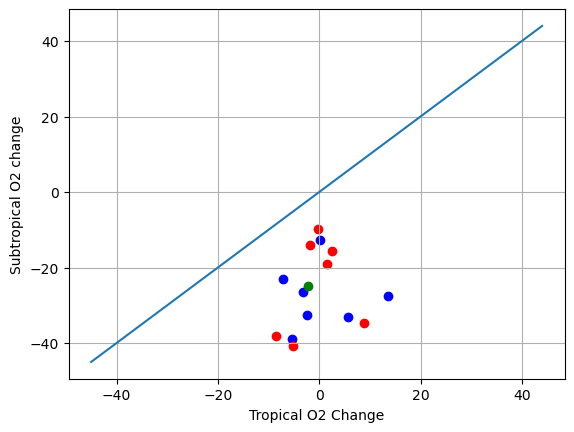

In [71]:
# from Ditkovsky et al 2025 .. 
# testing if this division of models clarifies which pattern is more reasonable - but it shows considerable spread
goodmod = ['UKESM1-0-LL', 'CanESM5-CanOE', 'MIROC-ES2L','GFDL-ESM4','GFDL-CM4','CanESM5','MRI-ESM2-0']

for sour in CMIPdata.source_id:
    if sour in goodmod:
        color = 'blue'
    else: 
        color = 'red'
    plt.scatter(Tro2.sel(source_id = sour),STo2.sel(source_id=sour), color = color)

plt.scatter(MIT_Tro2*1030, MIT_STo2*1030, color= 'g')


    
plt.plot(np.arange(-45,45), np.arange(-45,45))
plt.grid()
plt.xlabel('Tropical O2 Change')
plt.ylabel('Subtropical O2 change')



Text(0, 0.5, 'Subtropical Age change')

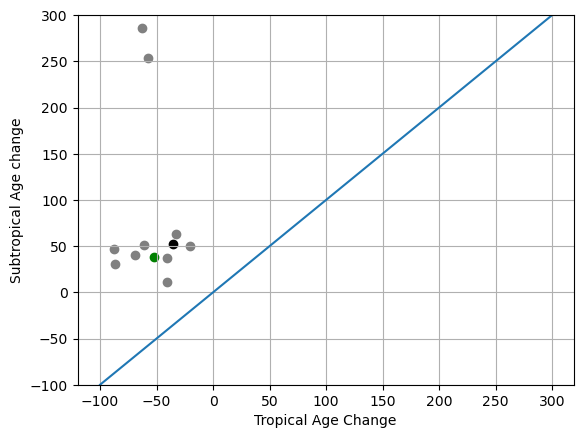

In [73]:
# same code but consolidated and for age 

# this is very sketchy and seems wrong, let's investigate! 

MIT_TrAge = Agetr.sel(XC = Trx, YC=Try, Z = Zsl).weighted(weights = MIT_vols).mean(['XC','YC','Z'])
MIT_STAge = Agetr.sel(XC = STx, YC=STy, Z = Zsl).weighted(weights = MIT_vols).mean(['XC','YC','Z'])


TrAge = CMIPdata.agessc.isel(time=1).sel(x = Trx, y=Try, lev = slice(200,1000)).weighted(weights = CMIP_weights).mean(['x','y','lev'])
STAge = CMIPdata.agessc.isel(time=1).sel(x = STx, y=STy, lev = slice(200,1000)).weighted(weights = CMIP_weights).mean(['x','y','lev'])


# not relevant probably 
goodmod = ['UKESM1-0-LL', 'CanESM5-CanOE', 'MIROC-ES2L','GFDL-ESM4','GFDL-CM4','CanESM5','MRI-ESM2-0']

for sour in CMIPdata.source_id:   
    plt.scatter(TrAge.sel(source_id = sour),STAge.sel(source_id=sour), color = 'gray', label = sour.values)
    
plt.scatter(MIT_TrAge, MIT_STAge, color= 'g')

axran = np.arange(-100,300)
plt.plot(axran, axran)
plt.ylim([-100,300])
plt.grid()
plt.xlabel('Tropical Age Change')
plt.ylabel('Subtropical Age change')
#plt.legend()





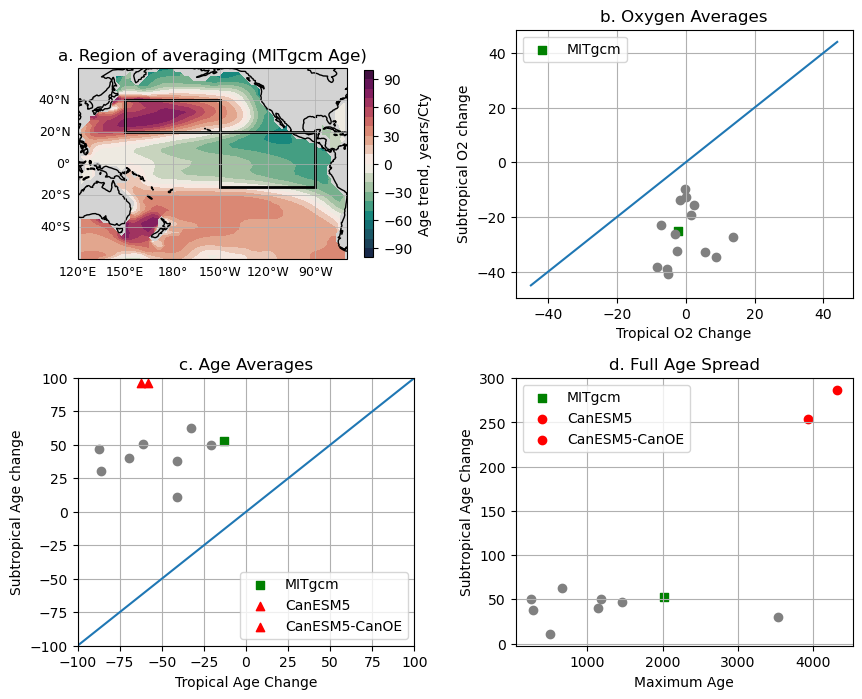

In [74]:
# Let's combine these figures. I'm not entirely sure how, but I think it's going to work. 


fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize=(10,8))

proj = ccrs.PlateCarree(central_longitude=180)
axs[0,0].remove()
axs[0,0] = fig.add_subplot(2,2,1, projection = proj)


#fig, axs = subplot_kw={'projection': proj})

deps = O2con.drF.isel(Z=zran)*O2con.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpAgetr = Agetr.isel( XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
tmpAgec = Agecontr.isel( XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 

PlAgetr = tmpAgetr.sum('Z')/deps.sum('Z')
PlAgec = tmpAgec.sum('Z')/deps.sum('Z')



#tmpMitAge = Ageconm.isel(XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
#PlAgemean = tmpMitAge.sum('Z')/deps.sum('Z')

MITagetr= axs[0,0].contourf(O2con.XC.isel(XC=xran), O2con.YC, (PlAgetr-PlAgec) , cmap = agemap, vmin=-100, vmax = 100, levels = np.linspace(-100, 100,21), transform=ccrs.PlateCarree(), )
plt.colorbar(MITagetr, ax = axs[0,0], shrink = 0.7, label = 'Age trend, years/Cty')

#MITo2mean= axs[0,0].contour(O2con.XC.isel(XC=xran), O2con.YC, PlAgemean , colors = 'k', linewidths = 1, levels = agelevels, transform=ccrs.PlateCarree())
#MITo2mean.clabel()
axs[0,0].set_title('a. Region of averaging (MITgcm Age)')

myaxs = axs[0,0]

ax = myaxs
ax.grid()
ax.coastlines()
ax.set_ylim([-60,60])
ax.set_xlim([-60,110])
gl = ax.gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels=False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}
ax.set_facecolor('lightgray')


import matplotlib.patches as patches


# 3. Create the rectangle patch
# Rectangle((x, y), width, height, ...)
rect = patches.Rectangle((150, 20), 60, 20, 
                         linewidth=2, 
                         edgecolor='k', 
                         facecolor='none', transform=ccrs.PlateCarree(), ) 

# 4. Add the patch to the Axes
axs[0,0].add_patch(rect)

rect2 = patches.Rectangle((210, -15), 60, 35, 
                         linewidth=2, 
                         edgecolor='k', 
                         facecolor='none', transform=ccrs.PlateCarree(), ) 

# 4. Add the patch to the Axes
axs[0,0].add_patch(rect2)






## O2 scatter code 

goodmod = ['UKESM1-0-LL', 'CanESM5-CanOE', 'MIROC-ES2L','GFDL-ESM4','GFDL-CM4','CanESM5','MRI-ESM2-0']
axs[0,1].scatter(MIT_Tro2*1030, MIT_STo2*1030, color= 'g', label = 'MITgcm',marker = 's')
for sour in CMIPdata.source_id:
    if sour in goodmod:
        color = 'lightblue'
    else: 
        color = 'pink'
    axs[0,1].scatter(Tro2.sel(source_id = sour),STo2.sel(source_id=sour), color = 'gray',)
    


#axs[0].scatter(MIT_gl_Tro2*1030, MIT_gl_STo2*1030, color= 'g')
axs[0,1].legend()
    
axs[0,1].plot(np.arange(-45,45), np.arange(-45,45))
axs[0,1].grid()
axs[0,1].set_xlabel('Tropical O2 Change')
axs[0,1].set_ylabel('Subtropical O2 change')

axs[0,1].set_title('b. Oxygen Averages')
axs[1,0].set_title('c. Age Averages')
axs[1,1].set_title('d. Full Age Spread')


## age code 

MIT_TrAge = Agetr.sel(XC = Trx, YC=STy, Z = Zsl).weighted(weights = MIT_vols).mean(['XC','YC','Z'])
MIT_STAge = Agetr.sel(XC = STx, YC=STy, Z = Zsl).weighted(weights = MIT_vols).mean(['XC','YC','Z'])

MIT_gl_TrAge = Agetr_dif.sel(XC = Trx, YC=STy, Z = Zsl).weighted(weights = MIT_vols).mean(['XC','YC','Z'])
MIT_gl_STAge = Agetr_dif.sel(XC = STx, YC=STy, Z = Zsl).weighted(weights = MIT_vols).mean(['XC','YC','Z'])

axs[1,0].scatter(MIT_TrAge, MIT_STAge, color= 'g', label = 'MITgcm', marker = 's')
#axs[1].scatter(MIT_gl_TrAge, MIT_gl_STAge, color= 'g')

for sour in CMIPdata.source_id:   
    if str(sour.values)[:3] =='Can':
        axs[1,0].scatter(TrAge.sel(source_id = sour),96, color = 'red', marker = '^', label = sour.values)
    else: 
        axs[1,0].scatter(TrAge.sel(source_id = sour),STAge.sel(source_id=sour), color = 'gray',)
axs[1,0].legend()

axran = np.arange(-100,100)
axs[1,0].plot(axran, axran)
axs[1,0].set_ylim([-100,100])
axs[1,0].set_xlim([-100,100])
axs[1,0].grid()
axs[1,0].set_xlabel('Tropical Age Change')
axs[1,0].set_ylabel('Subtropical Age change')


### age extremes 
axs[1,1].scatter(Ageconm.max(), MIT_STAge, color= 'g',marker = 's', label = 'MITgcm')
for sour in CMIPdata.source_id: 
    if str(sour.values)[:3] =='Can':
        axs[1,1].scatter(CMIPdata.agessc.isel(time=0).sel(source_id = sour).max(),STAge.sel(source_id=sour), color = 'red', label = sour.values)
    else: 
        axs[1,1].scatter(CMIPdata.agessc.isel(time=0).sel(source_id = sour).max(),STAge.sel(source_id=sour), color = 'gray')
axs[1,1].set_xlabel('Maximum Age')
axs[1,1].set_ylabel('Subtropical Age Change')
axs[1,1].grid()


axs[1,1].legend()


fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(hspace=0.3)

#plt.savefig('../eps_figures/supp_CMIPscatter_5-5.eps')


## Figure 2: Full comparison in zonal mean. 

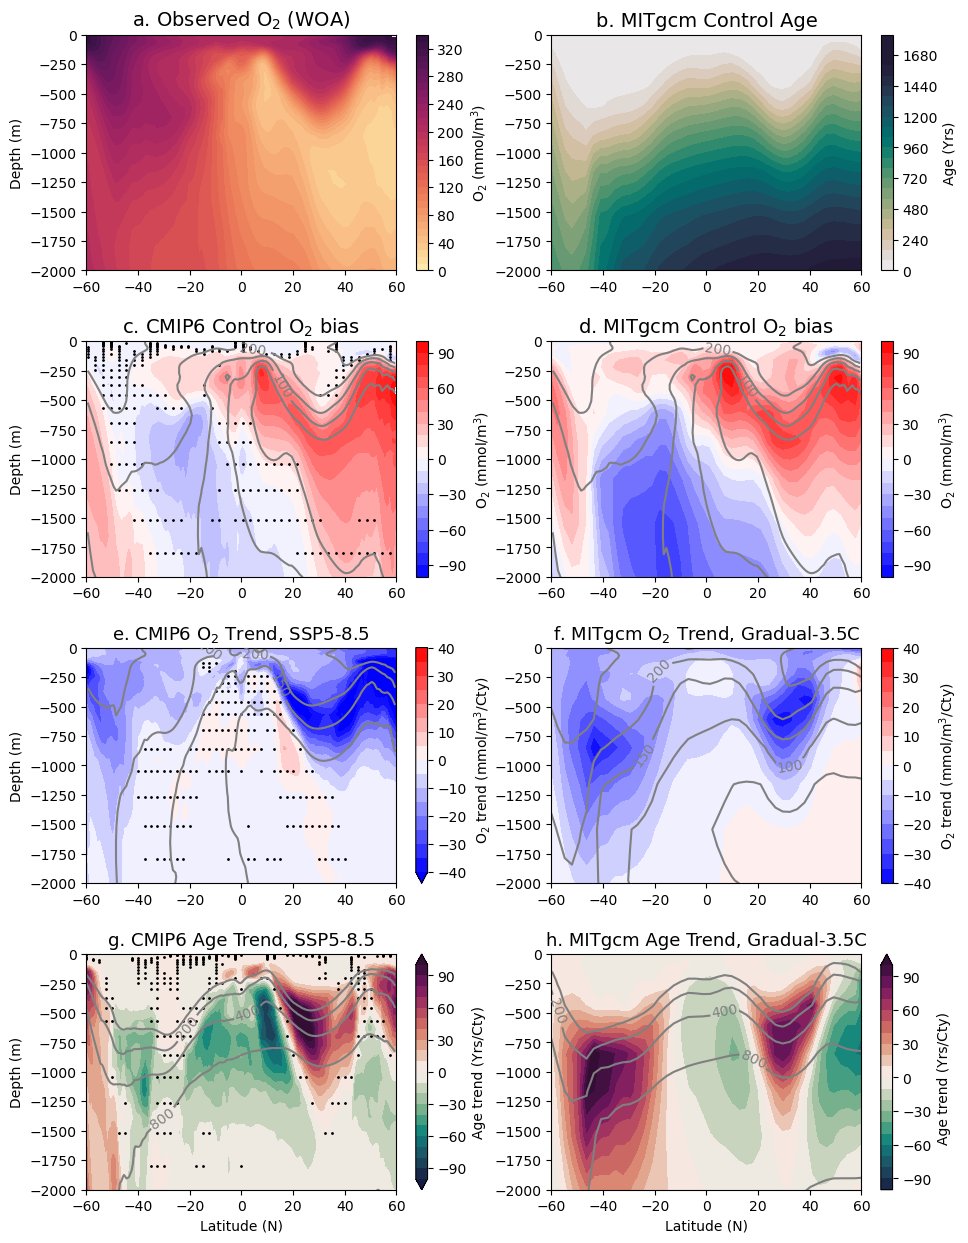

In [18]:


fig, axs = plt.subplots(ncols = 2, nrows =4, figsize=(11,15))
# latitudes are stuck to -60 and 60. But could give option for more detail. 
lons = np.arange(150, 210) # could also do full Pacific? That will kill the 
myX = lons - 50
mydep =2000
cmapox = cmocean.cm.matter
cmapage = cmocean.cm.curl
cmapagem = cmocean.cm.rain

WOA_reg_x = WOA_regrid.isel(x=myX).mean('x')
o2levs = [60,100, 150, 200,250]

mitlon = np.arange(int(lons[0]*128/360)+1, int(lons[-1]*128/360)+1)


O2obs = axs[0,0].contourf(cmipdif.y, -cmipdif.lev, WOA_reg_x*1.03, levels = np.linspace(0,340, 35), cmap = cmapox)
cbWOA = plt.colorbar(O2obs, ax = axs[0,0])
cbWOA.set_label('O$_2$ (mmol/m$^3$)')
axs[0,0].set_ylim([-mydep,0])
axs[0,0].set_xlim([-60,60])

Ageconmx = Ageconm.isel(XC=mitlon).mean('XC')#.mean('time')
MITagecon= axs[0,1].contourf(O2con.YC, O2con.Z, np.squeeze(Ageconmx), cmap = cmapagem, levels = 25, vmin=0, vmax = 1600)
#axs[0,1].contour(O2cont.YC, O2cont.Z, agecont.isel(XC=mitlon).mean('XC').mean('time') , colors = 'gray', levels = agelevs)
axs[0,1].set_ylim([-2000,0])
axs[0,1].set_xlim([-60,60])
cbage = plt.colorbar(MITagecon, ax = axs[0,1])
cbage.set_label('Age (Yrs)')

## bias calculations 



# bias stippling code. 
xmbi_sour = CMIPdata.o2.isel(time=0, x=myX, lev= range(0,55)).mean('x') - WOA_reg_x
signs = np.sign(xmbi_sour)
nans = np.isnan(xmbi_sour)

#Count how many models have the same sign at each grid cell
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)

agreement_bi = (pos_count +  nan_count < 10) & (neg_count+nan_count < 10)# & ~(np.isnan(cmip_o2tr_pl))
mask_bi = agreement_bi.values
stepy = 3
stepz = 2

levs_tmp = -CMIPdata.lev.isel(lev = range(55)).values
lats_tmp = xmbi_sour.y.values
lat_np, lev_np = np.meshgrid(lats_tmp, levs_tmp) 

axs[1,0].set_ylim([-mydep,0])
axs[1,0].set_xlim([-60,60])
CMIPbias = axs[1,0].contourf(cmipdif.y, -cmipdif.lev, cmipdif.isel(x=myX).mean('x')*1.03,  cmap = 'bwr', levels =np.linspace(-100,100,21))
cbCMIPbi = plt.colorbar(CMIPbias, ax = axs[1,0])
cbCMIPbi.set_label('O$_2$ (mmol/m$^3$)')

woacont = axs[1,0].contour(cmipdif.y, -cmipdif.lev, WOA_reg_x*1.035, levels = o2levs, colors= 'gray' )
plt.clabel(woacont, [100, 200])

axs[1,0].scatter(
    lat_np[::stepz, ::stepy][mask_bi[::stepz, ::stepy]],
    lev_np[::stepz, ::stepy][mask_bi[::stepz, ::stepy]],
    color='k', s=1
)

axs[1,1].set_ylim([-2000,0])
axs[1,1].set_xlim([-60,60])
toPl = 1000*np.squeeze(O2conm.isel(XC=mitlon).mean('XC')) - 1.035*WOA_MITg.isel(XC=mitlon).mean('XC')
MITbias= axs[1,1].contourf(O2con.YC, O2con.Z, toPl , cmap = 'bwr', levels =np.linspace(-100,100,21))#vmin=-100, vmax = 100, levels = 25)

woacont2 = axs[1,1].contour(cmipdif.y, -cmipdif.lev, WOA_reg_x*1.035, levels = o2levs, colors= 'gray' )
plt.clabel(woacont2, [100, 200])

cbMITbi = plt.colorbar(MITbias, ax = axs[1,1])
#cbMITbi.set_label('O$_2$ ($\\mu$mol/kg)')
cbMITbi.set_label('O$_2$ (mmol/m$^3$)')


## O2 Trend comparison here. O2

levs_tmp = -CMIPdata.lev.isel(lev = range(55)).values
lats_tmp = CMIPdata.y.values
lat_np, lev_np = np.meshgrid(lats_tmp, levs_tmp) 

xmo2_sour = CMIPdata.o2.isel(time = 1, x=myX, lev= range(0,55)).mean('x')
signs = np.sign(xmo2_sour)
nans = np.isnan(xmo2_sour)

#Count how many models have the same sign at each grid cell
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)

agreement_o2 = (pos_count +  nan_count < 10) & (neg_count+nan_count < 10)# & ~(np.isnan(cmip_o2tr_pl))
mask_o2 = agreement_o2.values
stepy = 5
stepz = 2




axs[2,0].set_ylim([-2000,0])
axs[2,0].set_xlim([-60,60]) 
slice = CMIPdata.o2.isel(time = 1, x=myX, lev= range(0,55)).mean('x').median('source_id')
CMIPtr = axs[2,0].contourf(CMIPdata.y, -CMIPdata.lev[0:55], slice*1.035, cmap = 'bwr', levels =np.linspace(-40,40,17), extend = 'min')#vmin = -40, vmax = 40, levels = 25)
cmipmo2 = axs[2,0].contour( cmipdif.y, -cmipdif.lev, CMIPmno2.isel(x=myX).mean('x')*1.03 , levels = o2levs, colors= 'gray' )

plt.clabel(cmipmo2, [100, 150, 200])
cbCMIPo = plt.colorbar(CMIPtr, ax= axs[2,0])
cbCMIPo.set_label('O$_2$ trend (mmol/m$^3$/Cty)')

axs[2,0].scatter(
    lat_np[::stepz, ::stepy][mask_o2[::stepz, ::stepy]],
    lev_np[::stepz, ::stepy][mask_o2[::stepz, ::stepy]],
    color='k', s=1
)


#np.arange(int(lons[0]*128/360)+1, int(lons[-1]*128/360)+1)
# this is a hack because .sel was throwing an error. 
axs[2,1].set_ylim([-2000,0])
axs[2,1].set_xlim([-60,60])
toPl = O2tr.isel(XC=mitlon).mean('XC') - O2contr.isel(XC=mitlon).mean('XC')
MITtr= axs[2,1].contourf(O2con.YC, O2con.Z, 1000*np.squeeze(toPl) , cmap = 'bwr', levels =np.linspace(-40,40,17))#vmin=-40, vmax = 40, levels = 25)
mitmo2 = axs[2,1].contour(O2con.YC, O2con.Z, 1000*O2conm.isel(XC=mitlon).mean('XC'), levels = o2levs, colors= 'gray' )
plt.clabel(mitmo2, [100,150, 200])

cbMIT = plt.colorbar(MITtr, ax = axs[2,1])
cbMIT.set_label('O$_2$ trend (mmol/m$^3$/Cty)')



## age code here. 


xmage_sour = CMIPdata.agessc.isel(time = 1, x=myX, lev= range(0,55)).mean('x')
signs = np.sign(xmage_sour)
nans = np.isnan(xmage_sour)

#Count how many models have the same sign at each grid cell
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)
# There are 4 that automatically give nan's, so we want agreement of at least 7 of 10 (thus 11 total). 
agreement_age = (pos_count +  nan_count < 11) & (neg_count+nan_count < 11)# & ~(np.isnan(cmip_o2tr_pl))

stepy = 5
stepz = 2
mask_age = agreement_age.values
#ask_o2 = agreement_o2.values

agelevs = [100,200,400, 800,1600]

axs[3,0].set_ylim([-2000,0])
axs[3,0].set_xlim([-60,60]) 
slice = CMIPdata.agessc.isel(time = 1, x=myX, lev= range(0,55)).mean('x').median('source_id')
CMIPagetr = axs[3,0].contourf(CMIPdata.y, -CMIPdata.lev[0:55], slice, cmap = cmapage,levels =np.linspace(-100,100,21), extend = 'both')  #vmin = -80, vmax = 80, levels = 25)
cmipmage = axs[3,0].contour(CMIPdata.y, -CMIPdata.lev[0:55], CMIPdata.agessc.isel(time = 0, x=myX, lev= range(0,55)).mean('x').mean('source_id'), levels = agelevs, colors='gray')
plt.clabel(cmipmage, [200, 400, 800])
cbCMIPa =plt.colorbar(CMIPagetr, ax= axs[3,0])
cbCMIPa.set_label('Age trend (Yrs/Cty)')


axs[3,0].scatter(
    lat_np[::stepz, ::stepy][mask_age[::stepz, ::stepy]],
    lev_np[::stepz, ::stepy][mask_age[::stepz, ::stepy]],
    color='k', s=1
)


axs[3,1].set_ylim([-2000,0])
axs[3,1].set_xlim([-60,60])
toPl = Agetr.isel(XC=mitlon).mean('XC') - Agecontr.isel(XC=mitlon).mean('XC')
MITagetr= axs[3,1].contourf(O2con.YC, O2con.Z, np.squeeze(toPl) , cmap = cmapage, levels =np.linspace(-100,100,21), extend = 'max')
mitmage = axs[3,1].contour(O2con.YC, O2con.Z, Ageconm.isel(XC=mitlon).mean('XC'), colors = 'gray', levels = agelevs)
plt.clabel(mitmage, [200,400, 800])

cbMITa = plt.colorbar(MITagetr, ax = axs[3,1])
cbMITa.set_label('Age trend (Yrs/Cty)')

titlf = 14

axs[0,0].set_title('a. Observed O$_2$ (WOA)', fontsize = titlf)
axs[0,1].set_title('b. MITgcm Control Age', fontsize = titlf)
axs[1,0].set_title('c. CMIP6 Control O$_2$ bias', fontsize = titlf) 
axs[1,1].set_title('d. MITgcm Control O$_2$ bias', fontsize = titlf) 
axs[2,0].set_title('e. CMIP6 O$_2$ Trend, SSP5-8.5', fontsize = titlf-1) 
axs[2,1].set_title('f. MITgcm O$_2$ Trend, Gradual-3.5C', fontsize = titlf-1) 
axs[3,0].set_title('g. CMIP6 Age Trend, SSP5-8.5', fontsize = titlf-1) 
axs[3,1].set_title('h. MITgcm Age Trend, Gradual-3.5C', fontsize = titlf-1) 

axs[3,0].set_xlabel('Latitude (N)')
axs[3,1].set_xlabel('Latitude (N)')
axs[0,0].set_ylabel('Depth (m)') 
axs[1,0].set_ylabel('Depth (m)') 
axs[2,0].set_ylabel('Depth (m)') 
axs[3,0].set_ylabel('Depth (m)') 

#axs[0,0].text(0.05, 0.9, 'a', fontsize=16, transform=axs[0,0].transAxes, ha='left', va='top', color = 'white')
#axs[0,1].text(0.05, 0.9, 'b', fontsize=16, transform=axs[0,1].transAxes, ha='left', va='top')
#axs[1,0].text(0.05, 0.9, 'c', fontsize=16, transform=axs[1,0].transAxes, ha='left', va='top')
#axs[1,1].text(0.05, 0.9, 'd', fontsize=16, transform=axs[1,1].transAxes, ha='left', va='top')
#axs[2,0].text(0.05, 0.9, 'e', fontsize=16, transform=axs[2,0].transAxes, ha='left', va='top')
#axs[2,1].text(0.05, 0.9, 'f', fontsize=16, transform=axs[2,1].transAxes, ha='left', va='top')
#axs[3,0].text(0.05, 0.9, 'g', fontsize=16, transform=axs[3,0].transAxes, ha='left', va='top')
#axs[3,1].text(0.05, 0.9, 'h', fontsize=16, transform=axs[3,1].transAxes, ha='left', va='top')


plt.subplots_adjust(hspace=0.3)
# plt.savefig('../eps_figures/CMIP_comp5-3.eps', bbox_inches="tight")




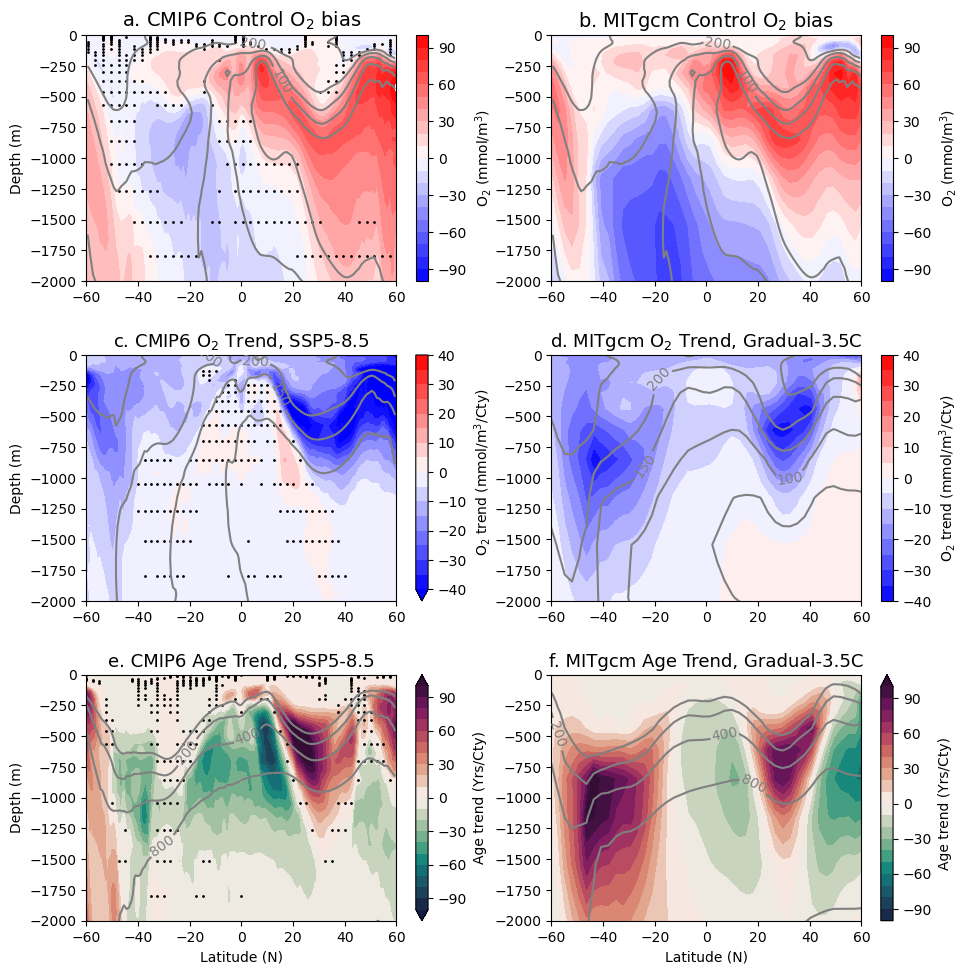

In [20]:
# New version of Fig 2 with panels a and b removed (so only 6 panels)

fig, axs = plt.subplots(ncols = 2, nrows =3, figsize=(11,11.5))
# latitudes are stuck to -60 and 60. But could give option for more detail. 
lons = np.arange(150, 210) # could also do full Pacific? That will kill the 
myX = lons - 50
mydep =2000
cmapox = cmocean.cm.matter
cmapage = cmocean.cm.curl
cmapagem = cmocean.cm.rain



## bias calculations 



# bias stippling code. 
xmbi_sour = CMIPdata.o2.isel(time=0, x=myX, lev= range(0,55)).mean('x') - WOA_reg_x
signs = np.sign(xmbi_sour)
nans = np.isnan(xmbi_sour)

#Count how many models have the same sign at each grid cell
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)

agreement_bi = (pos_count +  nan_count < 10) & (neg_count+nan_count < 10)# & ~(np.isnan(cmip_o2tr_pl))
mask_bi = agreement_bi.values
stepy = 3
stepz = 2

levs_tmp = -CMIPdata.lev.isel(lev = range(55)).values
lats_tmp = xmbi_sour.y.values
lat_np, lev_np = np.meshgrid(lats_tmp, levs_tmp) 

axs[0,0].set_ylim([-mydep,0])
axs[0,0].set_xlim([-60,60])
CMIPbias = axs[0,0].contourf(cmipdif.y, -cmipdif.lev, cmipdif.isel(x=myX).mean('x')*1.03,  cmap = 'bwr', levels =np.linspace(-100,100,21))
cbCMIPbi = plt.colorbar(CMIPbias, ax = axs[0,0])
cbCMIPbi.set_label('O$_2$ (mmol/m$^3$)')

woacont = axs[0,0].contour(cmipdif.y, -cmipdif.lev, WOA_reg_x*1.035, levels = o2levs, colors= 'gray' )
plt.clabel(woacont, [100, 200])

axs[0,0].scatter(
    lat_np[::stepz, ::stepy][mask_bi[::stepz, ::stepy]],
    lev_np[::stepz, ::stepy][mask_bi[::stepz, ::stepy]],
    color='k', s=1
)

axs[0,1].set_ylim([-2000,0])
axs[0,1].set_xlim([-60,60])
toPl = 1000*np.squeeze(O2conm.isel(XC=mitlon).mean('XC')) - 1.035*WOA_MITg.isel(XC=mitlon).mean('XC')
MITbias= axs[0,1].contourf(O2con.YC, O2con.Z, toPl , cmap = 'bwr', levels =np.linspace(-100,100,21))#vmin=-100, vmax = 100, levels = 25)

woacont2 = axs[0,1].contour(cmipdif.y, -cmipdif.lev, WOA_reg_x*1.035, levels = o2levs, colors= 'gray' )
plt.clabel(woacont2, [100, 200])

cbMITbi = plt.colorbar(MITbias, ax = axs[0,1])
#cbMITbi.set_label('O$_2$ ($\\mu$mol/kg)')
cbMITbi.set_label('O$_2$ (mmol/m$^3$)')


## O2 Trend comparison here. O2

levs_tmp = -CMIPdata.lev.isel(lev = range(55)).values
lats_tmp = CMIPdata.y.values
lat_np, lev_np = np.meshgrid(lats_tmp, levs_tmp) 

xmo2_sour = CMIPdata.o2.isel(time = 1, x=myX, lev= range(0,55)).mean('x')
signs = np.sign(xmo2_sour)
nans = np.isnan(xmo2_sour)

#Count how many models have the same sign at each grid cell
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)

agreement_o2 = (pos_count +  nan_count < 10) & (neg_count+nan_count < 10)# & ~(np.isnan(cmip_o2tr_pl))
mask_o2 = agreement_o2.values
stepy = 5
stepz = 2




axs[1,0].set_ylim([-2000,0])
axs[1,0].set_xlim([-60,60]) 
slice = CMIPdata.o2.isel(time = 1, x=myX, lev= range(0,55)).mean('x').median('source_id')
CMIPtr = axs[1,0].contourf(CMIPdata.y, -CMIPdata.lev[0:55], slice*1.035, cmap = 'bwr', levels =np.linspace(-40,40,17), extend = 'min')#vmin = -40, vmax = 40, levels = 25)
cmipmo2 = axs[1,0].contour( cmipdif.y, -cmipdif.lev, CMIPmno2.isel(x=myX).mean('x')*1.03 , levels = o2levs, colors= 'gray' )

plt.clabel(cmipmo2, [100, 150, 200])
cbCMIPo = plt.colorbar(CMIPtr, ax= axs[1,0])
cbCMIPo.set_label('O$_2$ trend (mmol/m$^3$/Cty)')

axs[1,0].scatter(
    lat_np[::stepz, ::stepy][mask_o2[::stepz, ::stepy]],
    lev_np[::stepz, ::stepy][mask_o2[::stepz, ::stepy]],
    color='k', s=1
)


#np.arange(int(lons[0]*128/360)+1, int(lons[-1]*128/360)+1)
# this is a hack because .sel was throwing an error. 
axs[1,1].set_ylim([-2000,0])
axs[1,1].set_xlim([-60,60])
toPl = O2tr.isel(XC=mitlon).mean('XC') - O2contr.isel(XC=mitlon).mean('XC')
MITtr= axs[1,1].contourf(O2con.YC, O2con.Z, 1000*np.squeeze(toPl) , cmap = 'bwr', levels =np.linspace(-40,40,17))#vmin=-40, vmax = 40, levels = 25)
mitmo2 = axs[1,1].contour(O2con.YC, O2con.Z, 1000*O2conm.isel(XC=mitlon).mean('XC'), levels = o2levs, colors= 'gray' )
plt.clabel(mitmo2, [100,150, 200])

cbMIT = plt.colorbar(MITtr, ax = axs[1,1])
cbMIT.set_label('O$_2$ trend (mmol/m$^3$/Cty)')



## age code here. 


xmage_sour = CMIPdata.agessc.isel(time = 1, x=myX, lev= range(0,55)).mean('x')
signs = np.sign(xmage_sour)
nans = np.isnan(xmage_sour)

#Count how many models have the same sign at each grid cell
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)
# There are 4 that automatically give nan's, so we want agreement of at least 7 of 10 (thus 11 total). 
agreement_age = (pos_count +  nan_count < 11) & (neg_count+nan_count < 11)# & ~(np.isnan(cmip_o2tr_pl))

stepy = 5
stepz = 2
mask_age = agreement_age.values
#ask_o2 = agreement_o2.values

agelevs = [100,200,400, 800,1600]

axs[2,0].set_ylim([-2000,0])
axs[2,0].set_xlim([-60,60]) 
slice = CMIPdata.agessc.isel(time = 1, x=myX, lev= range(0,55)).mean('x').median('source_id')
CMIPagetr = axs[2,0].contourf(CMIPdata.y, -CMIPdata.lev[0:55], slice, cmap = cmapage,levels =np.linspace(-100,100,21), extend = 'both')  #vmin = -80, vmax = 80, levels = 25)
cmipmage = axs[2,0].contour(CMIPdata.y, -CMIPdata.lev[0:55], CMIPdata.agessc.isel(time = 0, x=myX, lev= range(0,55)).mean('x').mean('source_id'), levels = agelevs, colors='gray')
plt.clabel(cmipmage, [200, 400, 800])
cbCMIPa =plt.colorbar(CMIPagetr, ax= axs[2,0])
cbCMIPa.set_label('Age trend (Yrs/Cty)')

s
axs[2,0].scatter(
    lat_np[::stepz, ::stepy][mask_age[::stepz, ::stepy]],
    lev_np[::stepz, ::stepy][mask_age[::stepz, ::stepy]],
    color='k', s=1
)


axs[2,1].set_ylim([-2000,0])
axs[2,1].set_xlim([-60,60])
toPl = Agetr.isel(XC=mitlon).mean('XC') - Agecontr.isel(XC=mitlon).mean('XC')
MITagetr= axs[2,1].contourf(O2con.YC, O2con.Z, np.squeeze(toPl) , cmap = cmapage, levels =np.linspace(-100,100,21), extend = 'max')
mitmage = axs[2,1].contour(O2con.YC, O2con.Z, Ageconm.isel(XC=mitlon).mean('XC'), colors = 'gray', levels = agelevs)
plt.clabel(mitmage, [200,400, 800])

cbMITa = plt.colorbar(MITagetr, ax = axs[2,1])
cbMITa.set_label('Age trend (Yrs/Cty)')

titlf = 14

#axs[0,0].set_title('a. Observed O$_2$ (WOA)', fontsize = titlf)
#axs[0,1].set_title('b. MITgcm Control Age', fontsize = titlf)
axs[0,0].set_title('a. CMIP6 Control O$_2$ bias', fontsize = titlf) 
axs[0,1].set_title('b. MITgcm Control O$_2$ bias', fontsize = titlf) 
axs[1,0].set_title('c. CMIP6 O$_2$ Trend, SSP5-8.5', fontsize = titlf-1) 
axs[1,1].set_title('d. MITgcm O$_2$ Trend, Gradual-3.5C', fontsize = titlf-1) 
axs[2,0].set_title('e. CMIP6 Age Trend, SSP5-8.5', fontsize = titlf-1) 
axs[2,1].set_title('f. MITgcm Age Trend, Gradual-3.5C', fontsize = titlf-1) 

axs[2,0].set_xlabel('Latitude (N)')
axs[2,1].set_xlabel('Latitude (N)')
axs[0,0].set_ylabel('Depth (m)') 
axs[1,0].set_ylabel('Depth (m)') 
axs[2,0].set_ylabel('Depth (m)') 
#axs[3,0].set_ylabel('Depth (m)') 

#axs[0,0].text(0.05, 0.9, 'a', fontsize=16, transform=axs[0,0].transAxes, ha='left', va='top', color = 'white')
#axs[0,1].text(0.05, 0.9, 'b', fontsize=16, transform=axs[0,1].transAxes, ha='left', va='top')
#axs[1,0].text(0.05, 0.9, 'c', fontsize=16, transform=axs[1,0].transAxes, ha='left', va='top')
#axs[1,1].text(0.05, 0.9, 'd', fontsize=16, transform=axs[1,1].transAxes, ha='left', va='top')
#axs[2,0].text(0.05, 0.9, 'e', fontsize=16, transform=axs[2,0].transAxes, ha='left', va='top')
#axs[2,1].text(0.05, 0.9, 'f', fontsize=16, transform=axs[2,1].transAxes, ha='left', va='top')
#axs[3,0].text(0.05, 0.9, 'g', fontsize=16, transform=axs[3,0].transAxes, ha='left', va='top')
#axs[3,1].text(0.05, 0.9, 'h', fontsize=16, transform=axs[3,1].transAxes, ha='left', va='top')


plt.subplots_adjust(hspace=0.3)
# plt.savefig('../eps_figures/CMIP_comp5-13.eps', bbox_inches="tight")




## Including observational data

In [3]:
# Load data calculated in O2_obs_YT

# loading interpolated WOA data differences.  
P0293 = xr.open_dataset('../P02_2022minus1993_oxysig.nc')
P0204 = xr.open_dataset('../P02_2022minus2004_oxysig.nc')
P1691 = xr.open_dataset('../P16_2015minus1991_oxysig.nc')

Ito22f = '/glade/work/yeddebba/obs/Ito22_o2_g1x1.nc'
Ito22 = xr.open_dataset(Ito22f)

Ito22extf = '~/Ito22mapping_NCEIdata_5yrmean_67C0.nc'
Ito22ext = xr.open_dataset(Ito22extf) 

Ito24f = '/glade/work/yeddebba/obs/Ito24_o2_g1x1.nc'
#RB23f = '/glade/work/yeddebba/obs/RB23_o2_g1x1.nc'

In [19]:
# adding trend for RB

RB23f = '/glade/work/yeddebba/obs/RB23_o2_g1x1.nc'
RB23 = xr.open_dataset(RB23f)
# depth coord is same as Ito22, because they've been regridded by Yohei.
deps = np.array(RB23.depth)
lims = np.concatenate([[200],(deps[25:47]+deps[24:46])/2,[1000]])
depl = np.diff(lims)
depfull = np.concatenate([[0]*24, depl])
depfullxr = xr.DataArray(depfull, dims="depth", coords={"depth": RB23.depth})

tmp = RB23.oxygen_concentration_anomaly.isel(time = np.arange(7,58))*depfullxr # 1967 to 2017.
ans = tmp.sum('depth')/800
#coefsRB = ans.polyfit(dim='time', deg=1, cov=True)
coefsRB = ans.polyfit(dim='time', deg=1)
toPlRB = coefsRB.polyfit_coefficients.isel(degree=0)
 

#cov0 = coefsRB.polyfit_covariance.isel(cov_i=0, cov_j=0)
#uncRB = (cov0**0.5)# *Ito22ext.time.diff('time')[0]/ np.timedelta64(1,'ns')

In [ ]:
## computing the trend for Ito22 
deps = np.array(Ito22.depth)
lims = np.concatenate([[200],(deps[25:47]+deps[24:46])/2,[1000]])
depl = np.diff(lims)
depfull = np.concatenate([[0]*24, depl])
depfullxr = xr.DataArray(depfull, dims="depth", coords={"depth": Ito22.depth})

tmp = Ito22.o2.isel(time = np.arange(0,51))*depfullxr
ans = tmp.sum('depth')/800
coefs = ans.polyfit(dim='time', deg=1,)# cov=True)

rate = coefs.polyfit_coefficients.isel(degree=0)
yr = Ito22.time.diff('time')[0]
factor = yr/np.timedelta64(1,'ns') # nanoseconds in a year
toPl = rate*factor # now this gives the change in O2 (umol/kg) per year, I think. 

#cov0 = coefs.polyfit_covariance.isel(cov_i=0, cov_j=0)
#unc = (cov0**0.5)* factor# *Ito22ext.time.diff('time')[0]/ np.timedelta64(1,'ns')

In [5]:
Ito24 = xr.open_dataset(Ito24f)
ML24 = Ito24
nparr = np.array(Ito24.o2.isel(ens=0))
for t in range(56): 
    nparr[t,:,:,:] = np.array(Ito24.o2.isel(time =t).mean('ens').values)
Ito24ens = xr.DataArray(nparr, dims = Ito24.o2.isel(ens=0).dims, coords = Ito24.o2.isel(ens=0).coords)

In [9]:
## computing trend for Ito24 ML product

#ML24f = '/glade/work/yeddebba/obs/Ito24_o2_g1x1.nc'
#ML24 = xr.open_dataset(ML24f)
# depth coord is same as Ito22, because they've been regridded by Yohei.
deps = np.array(ML24.depth)
lims = np.concatenate([[200],(deps[11:20]+deps[10:19])/2,[1000]])
depl = np.diff(lims)
depfull = np.concatenate([[0]*10, depl])
depfullML = xr.DataArray(depfull, dims="depth", coords={"depth": ML24.depth})

tmp = Ito24ens.isel(time = np.arange(2,53))*depfullML # 1967 to 2017.
ans = tmp.sum('depth')/800
#coefsRB = ans.polyfit(dim='time', deg=1, cov=True)
coefsML = ans.polyfit(dim='time', deg=1)
toPlML = coefsML.polyfit_coefficients.isel(degree=0)

In [20]:

## computing the trend for Ito22ext 
depfull_ext = np.concatenate([[0]*24, depl, [0]*20])
depfullxr_ext = xr.DataArray(depfull_ext, dims="depth", coords={"depth": Ito22ext.depth})
#tmp = Ito22ext.o2*depfullxr_ext
# if we want only through 2017, use this: 
tmp = Ito22ext.o2.isel(time = range(51))*depfullxr_ext
ans = tmp.sum('depth')/800
coefs_ext = ans.polyfit(dim='time', deg=1, )#cov = True)

rate = coefs_ext.polyfit_coefficients.isel(degree=0)
#cov0_ext = coefs.polyfit_covariance.isel(cov_i=0, cov_j=0)
yr = Ito22ext.time.diff('time')[0]
factor = yr/np.timedelta64(1,'ns') # nanoseconds in a year
toPl_ext = rate * factor # now this gives the change in O2 (umol/kg) per year, I think. 

#unc_ext = (cov0_ext**0.5) *factor

<xarray.DataArray 'time' (time: 54)> Size: 432B
array(['1967-01-01T00:00:00.000000000', '1968-01-01T00:00:00.000000000',
       '1969-01-01T00:00:00.000000000', '1970-01-01T00:00:00.000000000',
       '1971-01-01T00:00:00.000000000', '1972-01-01T00:00:00.000000000',
       '1973-01-01T00:00:00.000000000', '1974-01-01T00:00:00.000000000',
       '1975-01-01T00:00:00.000000000', '1976-01-01T00:00:00.000000000',
       '1977-01-01T00:00:00.000000000', '1978-01-01T00:00:00.000000000',
       '1979-01-01T00:00:00.000000000', '1980-01-01T00:00:00.000000000',
       '1981-01-01T00:00:00.000000000', '1982-01-01T00:00:00.000000000',
       '1983-01-01T00:00:00.000000000', '1984-01-01T00:00:00.000000000',
       '1985-01-01T00:00:00.000000000', '1986-01-01T00:00:00.000000000',
       '1987-01-01T00:00:00.000000000', '1988-01-01T00:00:00.000000000',
       '1989-01-01T00:00:00.000000000', '1990-01-01T00:00:00.000000000',
       '1991-01-01T00:00:00.000000000', '1992-01-01T00:00:00.000000000',
       '1993-01-01T00:00:00.000000000', '1994-01-01T00:00:00.000000000',
       '1995-01-01T00:00:00.000000000', '1996-01-01T00:00:00.000000000',
       '1997-01-01T00:00:00.000000000', '1998-01-01T00:00:00.000000000',
       '1999-01-01T00:00:00.000000000', '2000-01-01T00:00:00.000000000',
       '2001-01-01T00:00:00.000000000', '2002-01-01T00:00:00.000000000',
       '2003-01-01T00:00:00.000000000', '2004-01-01T00:00:00.000000000',
       '2005-01-01T00:00:00.000000000', '2006-01-01T00:00:00.000000000',
       '2007-01-01T00:00:00.000000000', '2008-01-01T00:00:00.000000000',
       '2009-01-01T00:00:00.000000000', '2010-01-01T00:00:00.000000000',
       '2011-01-01T00:00:00.000000000', '2012-01-01T00:00:00.000000000',
       '2013-01-01T00:00:00.000000000', '2014-01-01T00:00:00.000000000',
       '2015-01-01T00:00:00.000000000', '2016-01-01T00:00:00.000000000',
       '2017-01-01T00:00:00.000000000', '2018-01-01T00:00:00.000000000',
       '2019-01-01T00:00:00.000000000', '2020-01-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 432B 1967-01-01 1968-01-01 ... 2020-01-01

Text(0.03, 0.94, 'a')

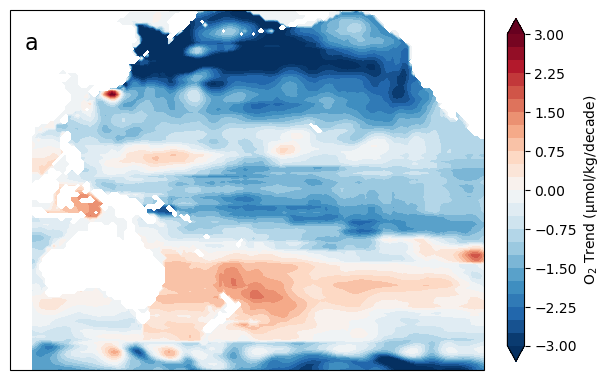

In [17]:
import matplotlib.gridspec as gridspec

proj = ccrs.PlateCarree(central_longitude=180)
fig = plt.figure(figsize=(6, 7.3), constrained_layout=True)
# --- SETUP ---
gs = gridspec.GridSpec(2, 1, figure=fig)
ax_map = fig.add_subplot(gs[0, 0], projection=proj)
#ax_p02 = fig.add_subplot(gs[1, 0])

#ax_p16 = fig.add_subplot(gs[2, 0])

#gs_inner_cell = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[2, 0], 
 #                                                 hspace=1, wspace=1)
#ax_p16 = fig.add_subplot(gs_inner_cell[0, 0])
# =============== MAP PANEL =================
toPl2 = toPlML * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific = da_360.isel(lon=np.arange(110, 260)).isel(lat=np.arange(30, 150))

cb = ax_map.contourf(pacific.lon, pacific.lat, 10*pacific, cmap='RdBu_r', vmin =-3, vmax = 3, levels = np.linspace(-3, 3, 25), extend = 'both',transform=ccrs.PlateCarree()) 
cbmap = plt.colorbar(cb,ax=ax_map, shrink = 0.95,  label='O$_2$ Trend (μmol/kg/decade)')
ax_map.text(0.03, 0.94, 'a', fontsize=16, transform=ax_map.transAxes, ha='left', va='top')


Text(0.5, 1.0, 'Observed O$_2$ Trend, 1965-2015 (Ito22)')

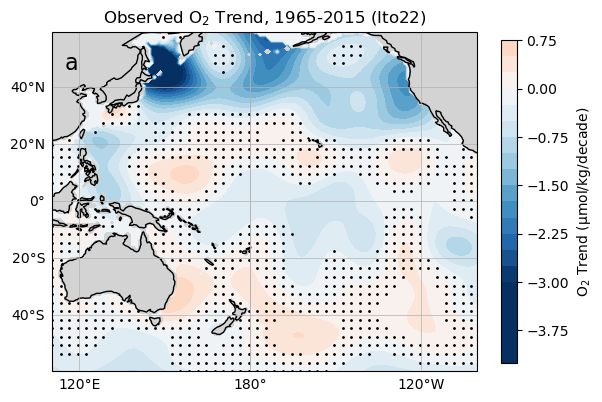

In [119]:
## Ito 22 with stippling!!

import matplotlib.gridspec as gridspec
# --- SETUP ---
proj = ccrs.PlateCarree(central_longitude=180)
fig = plt.figure(figsize=(6, 7.3), constrained_layout=True)

# Create 3 subplots: top one with map projection, bottom two are normal axes
gs = gridspec.GridSpec(2, 1, figure=fig)
ax_map = fig.add_subplot(gs[0, 0], projection=proj)
#ax_p02 = fig.add_subplot(gs[1, 0])

#ax_p16 = fig.add_subplot(gs[2, 0])

#gs_inner_cell = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[2, 0], 
 #                                                 hspace=1, wspace=1)
#ax_p16 = fig.add_subplot(gs_inner_cell[0, 0])
# =============== MAP PANEL =================
toPl2 = toPl * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific = da_360.isel(lon=np.arange(110, 260)).isel(lat=np.arange(30, 150))

cb = ax_map.contourf(pacific.lon, pacific.lat, 10*pacific, cmap='RdBu_r', vmin =-3, vmax = 3, levels = 20, transform=ccrs.PlateCarree()) 
cbmap = plt.colorbar(cb,ax=ax_map, shrink = 0.95,  label='O$_2$ Trend (μmol/kg/decade)')
ax_map.text(0.03, 0.94, 'a', fontsize=16, transform=ax_map.transAxes, ha='left', va='top')

lons_tmp = pacific.lon.values
lats_tmp = pacific.lat.values
lon_np, lat_np = np.meshgrid(lons_tmp, lats_tmp) 
# misnamed
stepy= 3
stepz=3


toPl2_unc = unc * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2_unc.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_unc = da_360.isel(lon=np.arange(110, 260)).isel(lat=np.arange(30, 150))
# 
mask_obs = np.abs(pacific)< 2*pacific_unc# & ~(np.isnan(cmip_o2tr_pl))

plt.scatter(
    lon_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
    lat_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
    color='k', s=1, transform=ccrs.PlateCarree()
)

#cax = fig.add_axes([0.92, 0.55, 0.02, 0.32])  # [left, bottom, width, height]
#cbmap = plt.colorbar(cb, cax=cax, label='O$_2$ Trend (μmol/kg/decade)')

#pacific.plot(ax=axs, transform=ccrs.PlateCarree(), cmap='RdBu_r')

ax_map.coastlines()
gl = ax_map.gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels = False
gl.right_labels = False
ax_map.set_facecolor('lightgray')
#ax_map.set_title('Observed O$_2$ Change, 1965-2015 (Ito22)')
ax_map.set_title('Observed O$_2$ Trend, 1965-2015 (Ito22)')

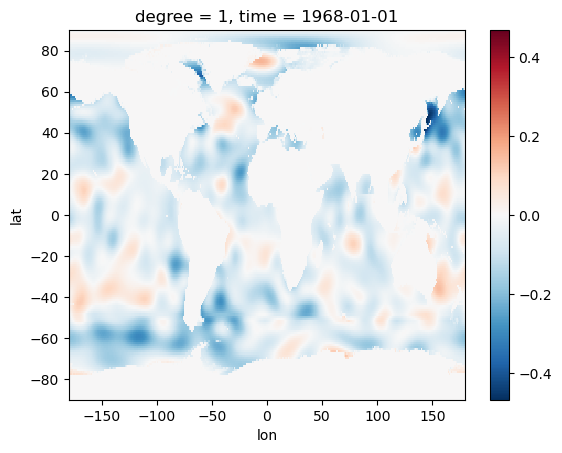

In [166]:
toPl_ext.plot()

Text(0.5, 1.0, 'e. Observed O$_2$ Trend, 1967-2020 (Ito22_ext)')

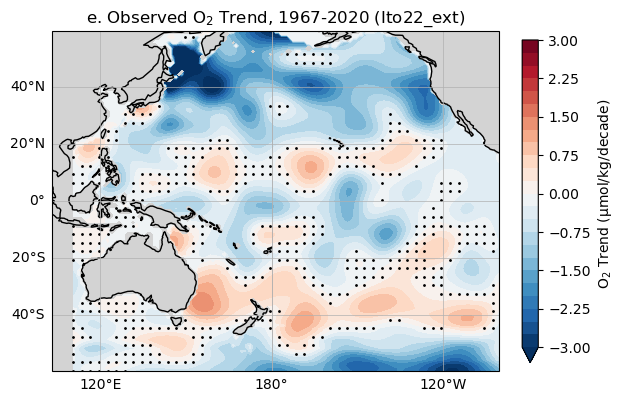

In [167]:
## REWRITING for only Ito22_ext with scatter. 

import matplotlib.gridspec as gridspec
# --- SETUP ---
proj = ccrs.PlateCarree(central_longitude=180)
fig = plt.figure(figsize=(6, 7.3), constrained_layout=True)

# Create 3 subplots: top one with map projection, bottom two are normal axes
gs = gridspec.GridSpec(2, 1, figure=fig)
ax_map = fig.add_subplot(gs[0, 0], projection=proj)

toPl2 = toPl_ext * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_ext = da_360.isel(lon=np.arange(110, 260)).isel(lat=np.arange(30, 150))

cb = ax_map.contourf(pacific.lon, pacific.lat, 10*pacific_ext, cmap='RdBu_r', vmin =-3, vmax = 3, levels = np.linspace(-3, 3, 25),extend = 'min', transform=ccrs.PlateCarree()) 
cbmap = plt.colorbar(cb,ax=ax_map, shrink = 0.95,  label='O$_2$ Trend (μmol/kg/decade)')
#ax_map.text(0.03, 0.94, 'a', fontsize=16, transform=ax_map.transAxes, ha='left', va='top')

lons_tmp = pacific.lon.values
lats_tmp = pacific.lat.values
lon_np, lat_np = np.meshgrid(lons_tmp, lats_tmp) 
# misnamed
stepy= 3
stepz=3


toPl2_unc = unc_ext * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2_unc.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_unc_ext = da_360.isel(lon=np.arange(110, 260)).isel(lat=np.arange(30, 150))
# 
mask_obs = np.abs(pacific_ext)< 2*pacific_unc_ext# & ~(np.isnan(cmip_o2tr_pl))

plt.scatter(
    lon_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
    lat_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
    color='k', s=1, transform=ccrs.PlateCarree()
)

#cax = fig.add_axes([0.92, 0.55, 0.02, 0.32])  # [left, bottom, width, height]
#cbmap = plt.colorbar(cb, cax=cax, label='O$_2$ Trend (μmol/kg/decade)')

#pacific.plot(ax=axs, transform=ccrs.PlateCarree(), cmap='RdBu_r')

ax_map.coastlines()
gl = ax_map.gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels = False
gl.right_labels = False
ax_map.set_facecolor('lightgray')
#ax_map.set_title('Observed O$_2$ Change, 1965-2015 (Ito22)')
ax_map.set_title('e. Observed O$_2$ Trend, 1967-2020 (Ito22_ext)')

Text(0.5, 1.0, 'Observed O$_2$ Trend, 1967-2017 (RB23)')

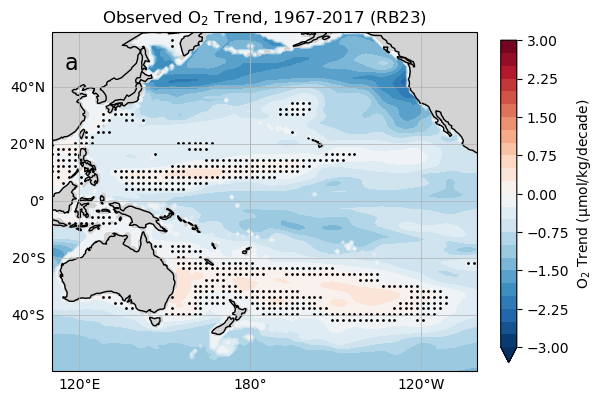

In [173]:
## REWRITING for RB23

import matplotlib.gridspec as gridspec
# --- SETUP ---
proj = ccrs.PlateCarree(central_longitude=180)
fig = plt.figure(figsize=(6, 7.3), constrained_layout=True)

# Create 3 subplots: top one with map projection, bottom two are normal axes
gs = gridspec.GridSpec(2, 1, figure=fig)
ax_map = fig.add_subplot(gs[0, 0], projection=proj)

toPl2 = toPlRB* Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacificRB = da_360.isel(lon=np.arange(110, 260)).isel(lat=np.arange(30, 150))

cb = plt.contourf(pacificRB.lon, pacificRB.lat, 10*pacificRB, cmap='RdBu_r', vmin =-3, vmax = 3,  levels = np.linspace(-3, 3, 25),extend = 'min', transform=ccrs.PlateCarree()) 
cbmap = plt.colorbar(cb,ax=ax_map, shrink = 0.95,  label='O$_2$ Trend (μmol/kg/decade)')
ax_map.text(0.03, 0.94, 'a', fontsize=16, transform=ax_map.transAxes, ha='left', va='top')

lons_tmp = pacific.lon.values
lats_tmp = pacific.lat.values
lon_np, lat_np = np.meshgrid(lons_tmp, lats_tmp) 
# misnamed
stepy= 2
stepz=2



toPl2_unc = uncRB * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2_unc.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_uncRB = da_360.isel(lon=np.arange(110, 260)).isel(lat=np.arange(30, 150))
# 
mask_obs = np.abs(pacificRB)< 2*pacific_uncRB# & ~(np.isnan(cmip_o2tr_pl))

plt.scatter(
    lon_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
    lat_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
    color='k', s=1, transform=ccrs.PlateCarree()
)

#cax = fig.add_axes([0.92, 0.55, 0.02, 0.32])  # [left, bottom, width, height]
#cbmap = plt.colorbar(cb, cax=cax, label='O$_2$ Trend (μmol/kg/decade)')

#pacific.plot(ax=axs, transform=ccrs.PlateCarree(), cmap='RdBu_r')

ax_map.coastlines()
gl = ax_map.gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels = False
gl.right_labels = False
ax_map.set_facecolor('lightgray')
#ax_map.set_title('Observed O$_2$ Change, 1965-2015 (Ito22)')
ax_map.set_title('Observed O$_2$ Trend, 1967-2017 (RB23)')

NameError: name 'unc_ext' is not defined

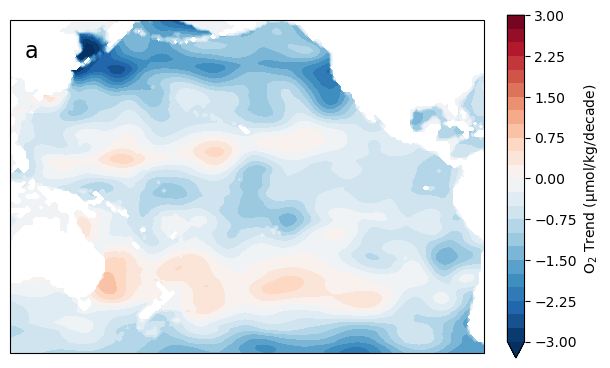

In [23]:
## Rewriting for both RB23 and Itoext (but redone to only 2017!!) to both have their uncertainty done. This is a bit tricky but not impossible! 



toPl_comb = (toPlRB + toPl_ext)/2

toPl2 = toPl_comb * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_comb = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

# using these just to compare for stippling!
toPl2 = toPl_ext * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_ext = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

toPl2 = toPlRB* Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacificRB = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

cb = plt.contourf(pacific_comb.lon, pacific_comb.lat, 10*pacific_comb, cmap='RdBu_r', vmin =-3, vmax = 3,  levels = np.linspace(-3, 3, 25),extend = 'min', transform=ccrs.PlateCarree()) 
cbmap = plt.colorbar(cb,ax=ax_map, shrink = 0.95,  label='O$_2$ Trend (μmol/kg/decade)')
ax_map.text(0.03, 0.94, 'a', fontsize=16, transform=ax_map.transAxes, ha='left', va='top')


#STIPPLING for panel e
lons_tmp = pacific_comb.lon.values
lats_tmp = pacific_comb.lat.values
lon_np, lat_np = np.meshgrid(lons_tmp, lats_tmp) 
# misnamed
stepy= 3
stepz=3
toPl2_unc = unc_ext * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2_unc.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_unc_ext = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

toPl2_unc = uncRB * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2_unc.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_uncRB = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))
# 
mask_obs = ((np.sign(pacificRB) != np.sign(pacific_ext)) & ~(np.isnan(pacificRB))) |(np.abs(pacificRB)< 2*pacific_uncRB) |  (np.abs(pacific_ext)<2*pacific_unc_ext)

plt.scatter(
    lon_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
    lat_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
    color='k', s=1, transform=ccrs.PlateCarree()
)


ax_map.coastlines()
gl = ax_map.gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels = False
gl.right_labels = False
ax_map.set_facecolor('lightgray')
#ax_map.set_title('Observed O$_2$ Change, 1965-2015 (Ito22)')
ax_map.set_title('Observed O$_2$ Trend, 1967-2017 (combined)')

Text(0.5, 1.0, 'Observed O$_2$ Trend, 1967-2017 (combined)')

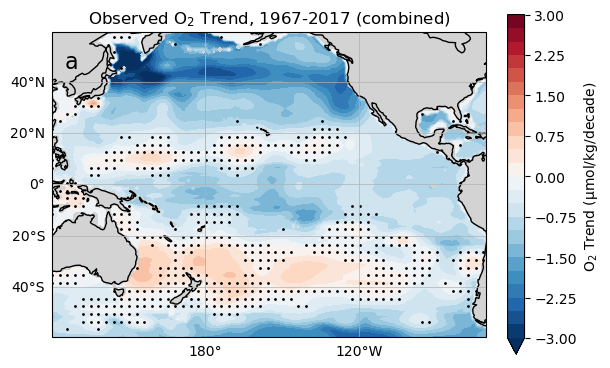

In [32]:
## Rewriting for RB23 and Itoext and Ito24 ML! No uncertainty measurements this time. Ok this is overwhelming 

import matplotlib.gridspec as gridspec
# --- SETUP ---
proj = ccrs.PlateCarree(central_longitude=180)
fig = plt.figure(figsize=(6, 7.3), constrained_layout=True)

# Create 3 subplots: top one with map projection, bottom two are normal axes
gs = gridspec.GridSpec(2, 1, figure=fig)
ax_map = fig.add_subplot(gs[0, 0], projection=proj)

toPl_comb = (toPlRB + toPl_ext + toPlML)/3

toPl2 = toPl_comb * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_comb = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

# using these just to compare for stippling!
toPl2 = toPl_ext * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_ext = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

toPl2 = toPlRB* Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacificRB = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

toPl2 = toPlML* Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacificML = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

cb = plt.contourf(pacific_comb.lon, pacific_comb.lat, 10*pacific_comb, cmap='RdBu_r', vmin =-3, vmax = 3,  levels = np.linspace(-3, 3, 25),extend = 'min', transform=ccrs.PlateCarree()) 
cbmap = plt.colorbar(cb,ax=ax_map, shrink = 0.95,  label='O$_2$ Trend (μmol/kg/decade)')
ax_map.text(0.03, 0.94, 'a', fontsize=16, transform=ax_map.transAxes, ha='left', va='top')

#STIPPLING for panel e
lons_tmp = pacific_comb.lon.values
lats_tmp = pacific_comb.lat.values
lon_np, lat_np = np.meshgrid(lons_tmp, lats_tmp) 
# misnamed
stepx= 3
stepy=3

mask_obs = ~(((np.sign(pacificRB) == np.sign(pacific_ext)) & (np.sign(pacificRB) == np.sign(pacificML))) | (np.isnan(pacificRB))) #|(np.abs(pacificRB)< 2*pacific_uncRB) |  (np.abs(pacific_ext)<2*pacific_unc_ext)

plt.scatter(
    lon_np[::stepx, ::stepy][mask_obs[::stepx, ::stepy]],
    lat_np[::stepx, ::stepy][mask_obs[::stepx, ::stepy]],
    color='k', s=1, transform=ccrs.PlateCarree()
)


ax_map.coastlines()
gl = ax_map.gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels = False
gl.right_labels = False
ax_map.set_facecolor('lightgray')
#ax_map.set_title('Observed O$_2$ Change, 1965-2015 (Ito22)')
ax_map.set_title('Observed O$_2$ Trend, 1967-2017 (combined)')

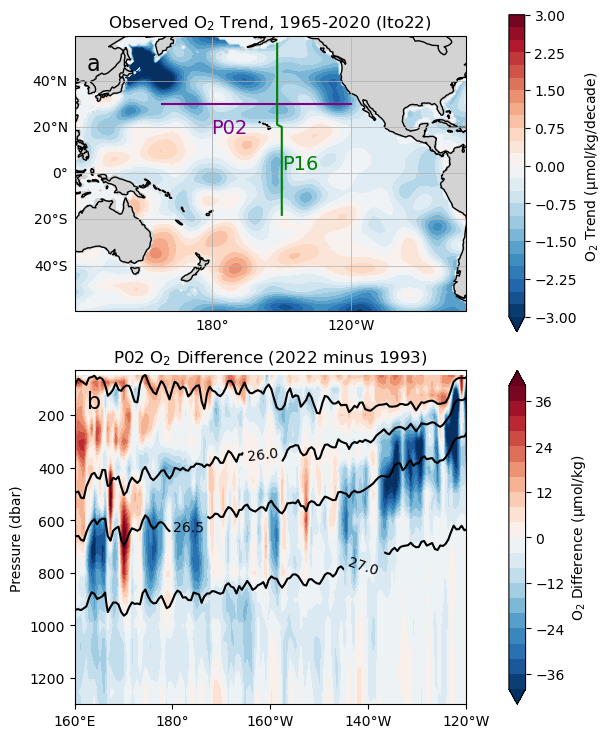

In [47]:
# Supplementary Figure S1 


# Updated to only include P02. 
# I'm thinking I might also want something with an earlier P16?? 


import matplotlib.gridspec as gridspec
# --- SETUP ---
proj = ccrs.PlateCarree(central_longitude=180)
fig = plt.figure(figsize=(6, 7.3), constrained_layout=True)

# Create 3 subplots: top one with map projection, bottom two are normal axes
gs = gridspec.GridSpec(2, 1, figure=fig)
ax_map = fig.add_subplot(gs[0, 0], projection=proj)
ax_p02 = fig.add_subplot(gs[1, 0])

#ax_p16 = fig.add_subplot(gs[2, 0])

#gs_inner_cell = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs[2, 0], 
 #                                                 hspace=1, wspace=1)
#ax_p16 = fig.add_subplot(gs_inner_cell[0, 0])
# =============== MAP PANEL =================


## calculating the full response: 

tmp = Ito22ext.o2*depfullxr_ext # full 2020 trend.
ans = tmp.sum('depth')/800
coefs_extfull = ans.polyfit(dim='time', deg=1, )#cov = True)

rate = coefs_extfull.polyfit_coefficients.isel(degree=0)
#cov0_ext = coefs.polyfit_covariance.isel(cov_i=0, cov_j=0)
yr = Ito22.time.diff('time')[0]
factor = yr/np.timedelta64(1,'ns') # nanoseconds in a year
toPl_extfull = rate * factor
toPl2 = toPl_extfull * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_xf = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

cb = ax_map.contourf(pacific_xf.lon, pacific_xf.lat, 10*pacific_xf, cmap='RdBu_r', vmin =-3, vmax = 3, levels = np.linspace(-3,3,25),  extend = 'min',transform=ccrs.PlateCarree()) 
cbmap = plt.colorbar(cb,ax=ax_map, shrink = 0.95,  label='O$_2$ Trend (μmol/kg/decade)')
ax_map.text(0.03, 0.94, 'a', fontsize=16, transform=ax_map.transAxes, ha='left', va='top')

#cax = fig.add_axes([0.92, 0.55, 0.02, 0.32])  # [left, bottom, width, height]
#cbmap = plt.colorbar(cb, cax=cax, label='O$_2$ Trend (μmol/kg/decade)')
#lons_tmp = pacific.lon.values
#lats_tmp = pacific.lat.values
#lon_np, lat_np = np.meshgrid(lons_tmp, lats_tmp) 
## misnamed
#stepy= 3
#stepz=3
##pacific.plot(ax=axs, transform=ccrs.PlateCarree(), cmap='RdBu_r')
#toPl2_unc = unc * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
#da_360 = toPl2_unc.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
#pacific_unc = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))
## 
#mask_obs = np.abs(pacific)< 2*pacific_unc# & ~(np.isnan(cmip_o2tr_pl))
#
#ax_map.scatter(
#    lon_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
#    lat_np[::stepy, ::stepz][mask_obs[::stepy, ::stepz]],
#    color='k', s=1, transform=ccrs.PlateCarree()
#)



ax_map.coastlines()
gl = ax_map.gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels = False
gl.right_labels = False
ax_map.set_facecolor('lightgray')
#ax_map.set_title('Observed O$_2$ Change, 1965-2015 (Ito22)')
ax_map.set_title('Observed O$_2$ Trend, 1965-2020 (Ito22)')
# Lines showing 
p2x = [158,240]
p2y =[30,30]
p16x = [210,210, 208,208]
#p16sx = 
p16y = [-18, 20,21, 56]
ax_map.plot(p2x, p2y, color='purple', transform=ccrs.PlateCarree())
ax_map.plot(p16x, p16y, color='g', transform=ccrs.PlateCarree())

# Helper for longitude labels
def lon_label(lon):
    if lon < 180:
        return f"{lon}°E"
    elif lon > 180:
        return f"{360-lon}°W"
    else:
        return "180°"

ticks = [140,160,180,200,220,240]

# =============== P02 SECTION (ZONAL) =================
c2 = ax_p02.contourf(
    P0293.longitude, P0293.pressure, P0293.oxy_diff,
    levels=np.linspace(-40,40,21), vmin=-40, vmax=40, cmap='RdBu_r', extend='both'
)
sig_lev = [25,26,26.5,27,27.4,27.7,28,28.3,28.6,29]
Csig = ax_p02.contour(P0293.longitude, P0293.pressure, P0293.sig0_grid,
                      colors='k', levels=sig_lev)
ax_p02.clabel(Csig, fmt='%1.1f')
ax_p02.invert_yaxis()
plt.colorbar(c2, ax=ax_p02, label='O$_2$ Difference (μmol/kg)')
ax_p02.set_title('P02 O$_2$ Difference (2022 minus 1993)')
#ax_p02.set_xlabel('Longitude')
ax_p02.set_xticks(ticks)
ax_p02.set_xticklabels([lon_label(l) for l in ticks])
ax_p02.set_ylabel('Pressure (dbar)')
ax_p02.set_ylim([1300, 30])
ax_p02.set_xlim([160,240])

## =============== P16 SECTION (MERIDIONAL) =================
#c16 = ax_p16.contourf(
#    P1691.latitude, P1691.pressure, P1691.oxy_diff,
#     levels=np.linspace(-40,40,21), vmin=-40, vmax=40, cmap='RdBu_r', extend='both'
#)
#Csig = ax_p16.contour(P1691.latitude, P1691.pressure, P1691.sig0_grid,
#                      colors='k', levels=sig_lev)
#ax_p16.clabel(Csig, fmt='%1.1f')
#ax_p16.invert_yaxis()
#plt.colorbar(c16, ax=ax_p16, label='O$_2$ Difference (μmol/kg)')
#ax_p16.set_title('P16 O$_2$ Difference (2015 minus 1991)')
#ax_p16.set_xlabel('Latitude (N)')
#ax_p16.set_ylabel('Pressure (dbar)')
#ax_p16.set_ylim([2000, 0])
gs.update(left=0.10, right=0.90)

ax_map.text(0.35, 0.7, 'P02', fontsize=14, color = 'purple', transform=ax_map.transAxes,ha='left', va='top')
ax_map.text(0.53, 0.57, 'P16', fontsize=14, color = 'g', transform=ax_map.transAxes,ha='left', va='top')
ax_p02.text(0.03, 0.94, 'b', fontsize=16, transform=ax_p02.transAxes,ha='left', va='top')
#ax_p16.text(0.03, 0.20, 'c', fontsize=14, transform=ax_p16.transAxes, ha='left', va='top')

# --- Final Layout ---
#plt.tight_layout()
#plt.show()

# plt.savefig('../eps_figures/Obs_supp_O2_5-14.eps', bbox_inches="tight")

## Figure 1 (CMIP6, MITgcm, and observations)

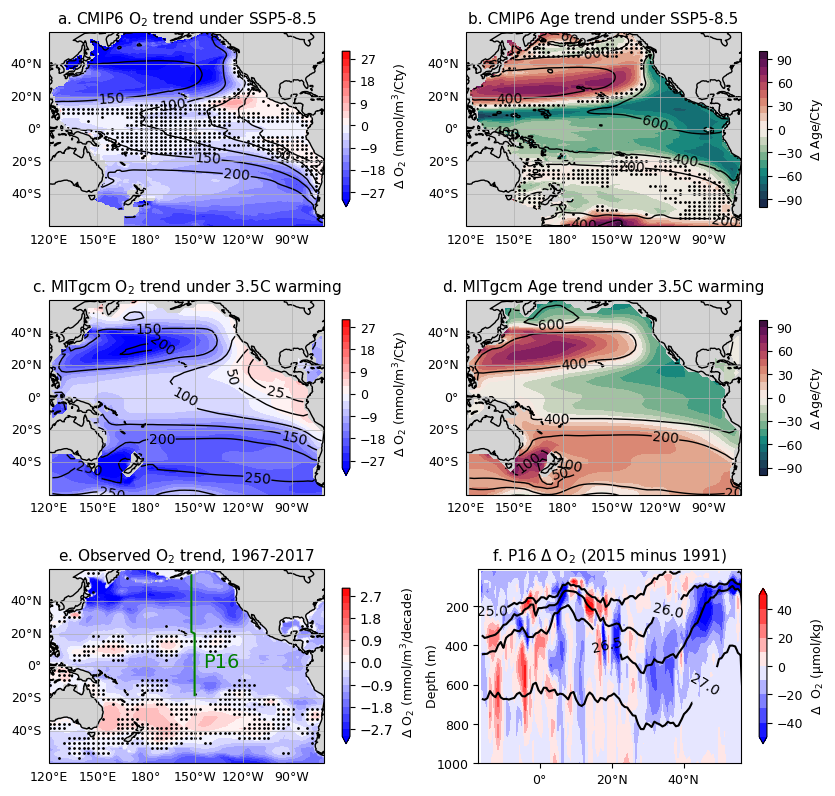

In [55]:
# Actual Figure 1

## OK a new version where I only want one of the WOCE things. 

# current version is fine; could also decrease colorbar label (and tick) fontsize, might help. 

import matplotlib.gridspec as gridspec

#fig = plt.figure(figsize=(10, 9.5))

# --- SETUP ---
proj = ccrs.PlateCarree(central_longitude=180)

# Normal subplots (first 5)

fig = plt.figure(figsize=(10,9.5))

# 3 rows, 4 columns
gs = gridspec.GridSpec(3, 8, figure=fig, hspace=0.38, wspace=1.3)

# Top row (each subplot spans 2 columns)
ax1 = fig.add_subplot(gs[0, 0:4], projection = proj)   # left top (columns 0 and 1)
ax3 = fig.add_subplot(gs[0, 4:8], projection = proj)   # right top (columns 2 and 3)

# Middle row (same pattern)
ax2 = fig.add_subplot(gs[1, 0:4], projection = proj)   # left middle
ax4 = fig.add_subplot(gs[1, 4:8], projection = proj)   # right middle

# Bottom row: repeated because I am playing around
ax5 = fig.add_subplot(gs[2, 0:4], projection = proj)   # columns 1 and 2 -> centered
ax6 = fig.add_subplot(gs[2, 4:8])
# Trying to make maps! 

#proj = ccrs.PlateCarree(central_longitude=180)
#fig, axs = plt.subplots(2, 2, figsize=(13, 7), subplot_kw={'projection': proj})
#axs = np.atleast_2d(axs)  # Ensure ax1 indexing works if only one row

# retrying this later, on 7-21, with the trends... 
# Now adding stippling on 8-12

#proj = ccrs.PlateCarree(central_longitude=180)
#fig, axs = plt.subplots(2, 2, figsize=(12, 7), subplot_kw={'projection': proj})
plt.subplots_adjust(wspace=0.13)
#axs = np.atleast_2d(axs)  # Ensure axs[0,0] indexing works if only one row

DIC50 = O2Gr

agemap = cmocean.cm.curl
agemap.set_bad(color='black')
cmapox = 'bwr'
#agemap.set_bad(color='black')
#fig, axs = plt.subplots(ncols=2 , nrows = 2,figsize=(12,8))

vm = 120
agelevels = [50, 100, 200, 400, 600, 800, 1200, 1600 ]
o2levels = [25,50,100,150,200,250] #[0.025,0.05, 0.1, 0.15, .2, .25 ]


#fig, axs = plt.subplots(ncols = 2, nrows =3, figsize=(13,12))
# latitudes are stuck to -60 and 60. But could give option for more detail. 
lons = np.arange(120, 290) # could also do full Pacific 
myX = lons - 50
#mydep = 2000 

k1=30
k2=46
mylevs = np.arange(k1,k2)

CMIPdrf= (np.array(CMIPdata.lev[(k1-1):k2].diff('lev'))+np.array(CMIPdata.lev[k1:(k2+1)].diff('lev')))/2
cmip_drf = xr.DataArray(
    CMIPdrf,
    dims=('lev'),
    coords={'lev': CMIPdata.lev[k1:k2]},
    name='cmip_drf')

sliceo2_sour = CMIPdata.o2.isel(time = 1, x= myX, lev= mylevs)
sliceo2 = sliceo2_sour.median('source_id')
cmip_o2tr_pl = sum(cmip_drf*sliceo2)/sum(cmip_drf)
depo2_sour = sum(cmip_drf*sliceo2_sour)/sum(cmip_drf)

sliceage_sour = CMIPdata.agessc.isel(time = 1, x=myX, lev= mylevs)
sliceage = sliceage_sour.median('source_id')
cmip_agetr_pl = sum(cmip_drf*sliceage)/sum(cmip_drf)
depage_sour = sum(cmip_drf*sliceage_sour)/sum(cmip_drf)

o2meantmp = CMIPdata.o2.isel(time = 0, x= myX, lev= mylevs).mean('source_id')
cmip_o2mean_pl = sum(cmip_drf*o2meantmp)/sum(cmip_drf)

agemeantmp = CMIPdata.agessc.isel(time = 0, x= myX, lev= mylevs).mean('source_id')
cmip_agemean_pl = sum(cmip_drf*agemeantmp)/sum(cmip_drf)

mapox = cmocean.cm.matter
zran = range(8,13)
yran = range(64)
xran = np.arange(int(lons[0]*128/360)+1, int(lons[-1]*128/360)+1)

# Let's do a proper depth average systematically here 
# first for MITgcm
deps = DIC50.drF.isel(Z=zran)*DIC50.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpO2tr = O2tr.isel( XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
tmpO2c = O2contr.isel( XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
tmpagetr = Agetr.isel( XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
tmpagec = Agecontr.isel(XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 

PlO2tr = tmpO2tr.sum('Z')/deps.sum('Z')
PlO2c = tmpO2c.sum('Z')/deps.sum('Z')
Plagetr = tmpagetr.sum('Z')/deps.sum('Z')
Plagec = tmpagec.sum('Z')/deps.sum('Z')

tmpMito2 = O2conm.isel(XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
PlO2mean = tmpMito2.sum('Z')/deps.sum('Z')

tmpMitage = Ageconm.isel(XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
PlAgemean = tmpMitage.sum('Z')/deps.sum('Z')
#slice = CMIPdata.o2.isel(time = 1, x= myX, lev= mylevs).mean('source_id')
#slice*

# mask for o2
signs = np.sign(depo2_sour)
nans = np.isnan(depo2_sour)

# Step 2: Count how many models have the same sign at each grid cell
# We’ll check separately for positive and negative
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)
# Step 3: Find where fewer than 10 agree on the sign
agreement_o2 = (pos_count +  nan_count < 10) & (neg_count+nan_count < 10)# & ~(np.isnan(cmip_o2tr_pl))

# repeat for age
signs = np.sign(depage_sour)
nans = np.isnan(depage_sour)

#Count how many models have the same sign at each grid cell
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)
# There are 4 that automatically give nan's, so we want agreement of at least 7 of 10 (thus 11 total). 
# should we change this to 12? 
agreement_age = (pos_count +  nan_count < 11) & (neg_count+nan_count < 11)# & ~(np.isnan(cmip_o2tr_pl))

stepx = 3
stepy = 5
mask_age = agreement_age.values
mask_o2 = agreement_o2.values

lon_np = CMIPdata.lon.isel(x = myX).values
lat_np = CMIPdata.lat.isel(x=myX).values

# Plot stippling for thinned mask
cbshr = 0.8

#slice = CMIPdata.o2.isel(time = 1, x= myX, lev= mylevs).mean('lev').mean('source_id')
CMIPtr = ax1.contourf(CMIPdata.x.isel(x=myX), CMIPdata.y, 1.03*cmip_o2tr_pl, vmin = -30, vmax = 30, levels = np.linspace(-30, 30,21), cmap = 'bwr',transform=ccrs.PlateCarree(), extend = 'min')
CMIPo2mean = ax1.contour(CMIPdata.x.isel(x=myX), CMIPdata.y, 1.03*cmip_o2mean_pl, colors= 'k', linewidths = 1, levels = o2levels,transform=ccrs.PlateCarree())
CMIPo2mean.clabel()
cbCMo = plt.colorbar(CMIPtr, ax = ax1, shrink = cbshr)
cbCMo.set_label('$\Delta$ O$_2$ (mmol/m$^3$/Cty)', fontsize = 9)
cbCMo.ax.tick_params(labelsize=9)
ax1.scatter(
    lon_np[::stepy, ::stepx][mask_o2[::stepy, ::stepx]],
    lat_np[::stepy, ::stepx][mask_o2[::stepy, ::stepx]],
    transform=ccrs.PlateCarree(),
    color='k', s=1
)
### MITgcm O2

#toPl = np.squeeze(O2tr.isel(Z=mitlevs, XC = mitlon).mean('Z'))-np.squeeze(O2contr.isel(Z=mitlevs, XC = mitlon).mean('Z')) 
MITo2tr= ax2.contourf(DIC50.XC.isel(XC=xran), DIC50.YC, 1000*(PlO2tr-PlO2c) , cmap = 'bwr', vmin=-30, vmax = 30, levels = np.linspace(-30, 30,21), extend = 'min', transform=ccrs.PlateCarree())
MITo2mean= ax2.contour(DIC50.XC.isel(XC=xran), DIC50.YC, 1000*PlO2mean , colors = 'k', linewidths = 1, levels = o2levels, transform=ccrs.PlateCarree())
MITo2mean.clabel()
#axs[0,1].set_ylim([-60,60])
#axs[0,1].set_xlim([lons[0],lons[-1]])
cbMITo = plt.colorbar(MITo2tr, ax = ax2, shrink = cbshr)
cbMITo.set_label('$\Delta$ O$_2$ (mmol/m$^3$/Cty)', fontsize = 9)
cbMITo.ax.tick_params(labelsize=9)
ax2.set_xlim([-60,110])

### CMIP age

CMIPagetr = ax3.contourf(CMIPdata.x.isel(x=myX), CMIPdata.y,cmip_agetr_pl, cmap = agemap, vmin = -100, vmax = 100, levels = np.linspace(-100,100,21), transform=ccrs.PlateCarree(), extend = 'neither')
CMIPagemean = ax3.contour(CMIPdata.x.isel(x=myX), CMIPdata.y, cmip_agemean_pl, colors= 'k', linewidths = 1, levels = agelevels,transform=ccrs.PlateCarree())
cl = CMIPagemean.clabel()
for txt in cl:
    txt.set_color('black') 
cbCMa= plt.colorbar(CMIPagetr, ax= ax3, shrink = cbshr)
cbCMa.set_label('$\Delta$ Age/Cty', fontsize = 9)
cbCMa.ax.tick_params(labelsize=9)
ax3.scatter(
    lon_np[::stepy, ::stepx][mask_age[::stepy, ::stepx]],
    lat_np[::stepy, ::stepx][mask_age[::stepy, ::stepx]],
    transform=ccrs.PlateCarree(),
    color='k', s=1
)
#### MITgcm age 

#toPl = age50.isel(Z=mitlevs, XC = mitlon).mean('Z') - agecont.isel(Z=mitlevs, XC = mitlon).mean('Z')
MITagetr= ax4.contourf(DIC50.XC.isel(XC=xran), DIC50.YC, np.squeeze(Plagetr-Plagec) , cmap = agemap, vmin=-100, vmax = 100, levels = np.linspace(-100, 100,21),transform=ccrs.PlateCarree(), extend = 'neither')
MITagemean= ax4.contour(DIC50.XC.isel(XC=xran), DIC50.YC, PlAgemean , colors = 'k', linewidths = 1, levels = agelevels, transform=ccrs.PlateCarree())
MITagemean.clabel()
#ax4.set_ylim([-60,60])
ax4.set_xlim([-60,110])
cbMITa = plt.colorbar(MITagetr, ax = ax4, shrink = cbshr)
cbMITa.set_label('$\Delta$ Age/Cty', fontsize = 9)
cbMITa.ax.tick_params(labelsize=9)
ax1.set_title('a. CMIP6 O$_2$ trend under SSP5-8.5', fontsize= 11) 
ax2.set_title('c. MITgcm O$_2$ trend under 3.5C warming', fontsize = 11) 
ax3.set_title('b. CMIP6 Age trend under SSP5-8.5', fontsize = 11) 
ax4.set_title('d. MITgcm Age trend under 3.5C warming', fontsize = 11) 


# =============== MAP PANEL =================
## Including both RB23 and Ito_ext (but redone to only 2017!!) to both have their uncertainty done.  

## Rewriting for RB23 and Itoext and Ito24 ML! No uncertainty measurements this time. Ok this is overwhelming 

toPl_comb = (toPlRB + toPl_ext + toPlML)/3 *1.03 # converting into the mmol/kg

toPl2 = toPl_comb * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_comb = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

# using these just to compare for stippling!
toPl2 = toPl_ext * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacific_ext = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

toPl2 = toPlRB* Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacificRB = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

toPl2 = toPlML* Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl2.lon + 360) % 360)).sortby("lon")
pacificML = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

cb = ax5.contourf(pacific_comb.lon, pacific_comb.lat, 10*pacific_comb, cmap='bwr', vmin =-3, vmax = 3,  levels = np.linspace(-3, 3, 21),extend = 'min', transform=ccrs.PlateCarree()) 
cbmap = plt.colorbar(cb, ax=ax5, shrink = cbshr) # label='O$_2$ Trend (μmol/kg/decade)')
#cbmapo = plt.colorbar(MITo2tr, ax = ax2, shrink = cbshr)
cbmap.set_label('$\Delta$ O$_2$ (mmol/m$^3$/decade)', fontsize = 9)

#ax_map.text(0.03, 0.94, 'a', fontsize=16, transform=ax_map.transAxes, ha='left', va='top')

#STIPPLING for panel e
lons_tmp = pacific_comb.lon.values
lats_tmp = pacific_comb.lat.values
lon_np, lat_np = np.meshgrid(lons_tmp, lats_tmp) 
# misnamed
stepx= 3
stepy=3

mask_obs = ~(((np.sign(pacificRB) == np.sign(pacific_ext)) & (np.sign(pacificRB) == np.sign(pacificML))) | (np.isnan(pacificRB))) #|(np.abs(pacificRB)< 2*pacific_uncRB) |  (np.abs(pacific_ext)<2*pacific_unc_ext)

ax5.scatter(
    lon_np[::stepx, ::stepy][mask_obs[::stepx, ::stepy]],
    lat_np[::stepx, ::stepy][mask_obs[::stepx, ::stepy]],
    color='k', s=1, transform=ccrs.PlateCarree()
)


ax5.set_title('e. Observed O$_2$ trend, 1967-2017', fontsize = 11)




## do the helpful mapping .. 

lets = ['a','b','c','d', 'e']
myaxs = [ax1, ax3, ax2, ax4, ax5] # I flipped b and c. 
for dig in range(5):
    ax = myaxs[dig]
    ax.grid()
    ax.coastlines()
    ax.set_ylim([-60,60])
    ax.set_xlim([-60,110])
    gl = ax.gridlines(draw_labels=True, linewidth=0.5)
    gl.top_labels=False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    ax.set_facecolor('lightgray')
    #ax.text(0.03, 0.96, lets[dig], fontsize=14, transform=ax.transAxes, ha='left', va='top')

# Helper for latitude labels

def lat_label(lat):
    if lat < 0:
        return f"{lat}°S"
    elif lat > 0:
        return f"{lat}°N"
    else:
        return "0°"

ticks = [140,160,180,200,220,240]
nticks = [0,20,40]

cbval = np.linspace(-50,50,11)

# =============== P16 SECTION (MERIDIONAL) =================

sig_lev = [25,26,26.5,27,27.4,27.7,28,28.3,28.6,29]
c16 = ax6.contourf(
    P1691.latitude, P1691.pressure, P1691.oxy_diff,
    levels=cbval, cmap='bwr', extend='both'
)
Csig = ax6.contour(P1691.latitude, P1691.pressure, P1691.sig0_grid,
                      colors='k', levels=sig_lev)
ax6.set_xlim([-17, 56])
ax6.clabel(Csig, fmt='%1.1f')
ax6.invert_yaxis()

ax6.set_box_aspect(0.74)
cbp16 = plt.colorbar(c16, ax=ax6, shrink = cbshr)
cbp16.set_label('$\Delta$  O$_2$ (μmol/kg)', fontsize = 9)
cbp16.ax.tick_params(labelsize=9)
ax6.set_title('f. P16 $\Delta$ O$_2$ (2015 minus 1991)', fontsize = 11)
ax6.tick_params(axis='y', labelsize=9)
ax6.set_xticks(nticks)
ax6.set_xticklabels([lat_label(l) for l in nticks])
ax6.tick_params(axis='x', labelsize=9)
#ax6b.set_xlabel('Latitude')
#ax6.set_ylabel('Pressure (dbar)')
ax6.set_ylim([1000, 10])

ax6.set_ylabel('Depth (m)', rotation = 90, fontsize = 9)
ax6.yaxis.set_label_coords(-0.15, 0.45)


#ax5.text(0.35, 0.7, 'P02', fontsize=14, color = 'g', transform=ax5.transAxes,ha='left', va='top')
ax5.text(0.56, 0.57, 'P16', fontsize=14, color = 'green', transform=ax5.transAxes,ha='left', va='top')
#ax6.text(0.03, 0.96, 'f', fontsize=14, transform=ax6.transAxes,ha='left', va='top')

#ax6.margins(x=0.2, y=0.1) 

p16x = [210,210, 208,208]
#p16sx = 
p16y = [-18, 20,21, 56]
#ax5.plot(p2x, p2y, color='g', transform=ccrs.PlateCarree())
ax5.plot(p16x, p16y, color='green', transform=ccrs.PlateCarree())


# --- Final Layout ---
#plt.tight_layout()
#plt.subplots_adjust(hspace=1)

#plt.savefig('../eps_figures/Fig1_with_obs5-17.eps', bbox_inches="tight")



In [ ]:
# This is a nice alternate Fig 1 (with a zonal section as panel g). 


#import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 9.5))

# --- SETUP ---
proj = ccrs.PlateCarree(central_longitude=180)

# Define a 3x2 grid
gs = gridspec.GridSpec(3, 2, figure=fig)

# Normal subplots (first 5)
ax1 = fig.add_subplot(gs[0, 0], projection = proj)
ax2 = fig.add_subplot(gs[0, 1], projection = proj)
ax3 = fig.add_subplot(gs[1, 0], projection = proj)
ax4 = fig.add_subplot(gs[1, 1], projection = proj)

# Trying to make maps! 

# retrying this later, on 7-21, with the trends... 
# I think I'm giving up on the previous version, and just going to make a new version here. 

# if we look at 400-800 m for instance we'll do better. 
# interesting ... 


#proj = ccrs.PlateCarree(central_longitude=180)
#fig, axs = plt.subplots(2, 2, figsize=(13, 7), subplot_kw={'projection': proj})
#axs = np.atleast_2d(axs)  # Ensure ax1 indexing works if only one row

# retrying this later, on 7-21, with the trends... 
# Now adding stippling on 8-12

#proj = ccrs.PlateCarree(central_longitude=180)
#fig, axs = plt.subplots(2, 2, figsize=(12, 7), subplot_kw={'projection': proj})
plt.subplots_adjust(wspace=0.13)
#axs = np.atleast_2d(axs)  # Ensure axs[0,0] indexing works if only one row

agemap = cmocean.cm.curl
agemap.set_bad(color='black')
cmapox = 'bwr'
#agemap.set_bad(color='black')
#fig, axs = plt.subplots(ncols=2 , nrows = 2,figsize=(12,8))

vm = 120
agelevels = [50, 100, 200, 400, 600, 800, 1200, 1600 ]
o2levels = [25,50,100,150,200,250] #[0.025,0.05, 0.1, 0.15, .2, .25 ]


#fig, axs = plt.subplots(ncols = 2, nrows =3, figsize=(13,12))
# latitudes are stuck to -60 and 60. But could give option for more detail. 
lons = np.arange(120, 290) # could also do full Pacific 
myX = lons - 50
#mydep = 2000 

k1=30
k2=46
mylevs = np.arange(k1,k2)

CMIPdrf= (np.array(CMIPdata.lev[(k1-1):k2].diff('lev'))+np.array(CMIPdata.lev[k1:(k2+1)].diff('lev')))/2
cmip_drf = xr.DataArray(
    CMIPdrf,
    dims=('lev'),
    coords={'lev': CMIPdata.lev[k1:k2]},
    name='cmip_drf')

sliceo2_sour = CMIPdata.o2.isel(time = 1, x= myX, lev= mylevs)
sliceo2 = sliceo2_sour.mean('source_id')
cmip_o2tr_pl = sum(cmip_drf*sliceo2)/sum(cmip_drf)
depo2_sour = sum(cmip_drf*sliceo2_sour)/sum(cmip_drf)

sliceage_sour = CMIPdata.agessc.isel(time = 1, x=myX, lev= mylevs)
sliceage = sliceage_sour.mean('source_id')
cmip_agetr_pl = sum(cmip_drf*sliceage)/sum(cmip_drf)
depage_sour = sum(cmip_drf*sliceage_sour)/sum(cmip_drf)

o2meantmp = CMIPdata.o2.isel(time = 0, x= myX, lev= mylevs).mean('source_id')
cmip_o2mean_pl = sum(cmip_drf*o2meantmp)/sum(cmip_drf)

agemeantmp = CMIPdata.agessc.isel(time = 0, x= myX, lev= mylevs).mean('source_id')
cmip_agemean_pl = sum(cmip_drf*agemeantmp)/sum(cmip_drf)

mapox = cmocean.cm.matter
zran = range(8,13)
yran = range(64)
xran = np.arange(int(lons[0]*128/360)+1, int(lons[-1]*128/360)+1)

# Let's do a proper depth average systematically here 
# first for MITgcm
deps = DIC50.drF.isel(Z=zran)*DIC50.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpO2tr = O2tr.isel( XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
tmpO2c = O2contr.isel( XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
tmpagetr = Agetr.isel( XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
tmpagec = Agecontr.isel(XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 

PlO2tr = tmpO2tr.sum('Z')/deps.sum('Z')
PlO2c = tmpO2c.sum('Z')/deps.sum('Z')
Plagetr = tmpagetr.sum('Z')/deps.sum('Z')
Plagec = tmpagec.sum('Z')/deps.sum('Z')

tmpMito2 = O2con.isel(XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
PlO2mean = tmpMito2.sum('Z')/deps.sum('Z')

tmpMitage = agecont.isel(XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
PlAgemean = tmpMitage.sum('Z')/deps.sum('Z')
#slice = CMIPdata.o2.isel(time = 1, x= myX, lev= mylevs).mean('source_id')
#slice*

# mask for o2
signs = np.sign(depo2_sour)
nans = np.isnan(depo2_sour)

# Step 2: Count how many models have the same sign at each grid cell
# We’ll check separately for positive and negative
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)
# Step 3: Find where fewer than 10 agree on the sign
agreement_o2 = (pos_count +  nan_count < 10) & (neg_count+nan_count < 10)# & ~(np.isnan(cmip_o2tr_pl))

# repeat for age
signs = np.sign(depage_sour)
nans = np.isnan(depage_sour)

#Count how many models have the same sign at each grid cell
pos_count = (signs > 0).sum(dim='source_id')
neg_count = (signs < 0).sum(dim='source_id')
nan_count = np.sum(nans,0)
# There are 4 that automatically give nan's, so we want agreement of at least 7 of 10 (thus 11 total). 
agreement_age = (pos_count +  nan_count < 11) & (neg_count+nan_count < 11)# & ~(np.isnan(cmip_o2tr_pl))

stepx = 3
stepy = 5
mask_age = agreement_age.values
mask_o2 = agreement_o2.values

lon_np = CMIPdata.lon.isel(x = myX).values
lat_np = CMIPdata.lat.isel(x=myX).values

# Plot stippling for thinned mask


#slice = CMIPdata.o2.isel(time = 1, x= myX, lev= mylevs).mean('lev').mean('source_id')
CMIPtr = ax1.contourf(CMIPdata.x.isel(x=myX), CMIPdata.y, 1.03*cmip_o2tr_pl, vmin = -30, vmax = 30, levels = np.linspace(-30, 30,21), cmap = 'bwr',transform=ccrs.PlateCarree(), extend = 'min')
CMIPo2mean = ax1.contour(CMIPdata.x.isel(x=myX), CMIPdata.y, 1.03*cmip_o2mean_pl, colors= 'k', linewidths = 1, levels = o2levels,transform=ccrs.PlateCarree())
CMIPo2mean.clabel()
cbCMo = plt.colorbar(CMIPtr, ax = ax1)
cbCMo.set_label('O$_2$ (mmol/m$^3$)')
ax1.scatter(
    lon_np[::stepy, ::stepx][mask_o2[::stepy, ::stepx]],
    lat_np[::stepy, ::stepx][mask_o2[::stepy, ::stepx]],
    transform=ccrs.PlateCarree(),
    color='k', s=1
)
#axs[1,0].set_ylim([-2000,0])
#axs[1,0].set_xlim([-60,60])

#toPl = np.squeeze(O2tr.isel(Z=mitlevs, XC = mitlon).mean('Z'))-np.squeeze(O2contr.isel(Z=mitlevs, XC = mitlon).mean('Z')) 
MITo2tr= ax2.contourf(DIC50.XC.isel(XC=xran), DIC50.YC, 1000*(PlO2tr-PlO2c) , cmap = 'bwr', vmin=-30, vmax = 30, levels = np.linspace(-30, 30,21), transform=ccrs.PlateCarree())
MITo2mean= ax2.contour(DIC50.XC.isel(XC=xran), DIC50.YC, 1000*PlO2mean , colors = 'k', linewidths = 1, levels = o2levels, transform=ccrs.PlateCarree())
MITo2mean.clabel()
#axs[0,1].set_ylim([-60,60])
#axs[0,1].set_xlim([lons[0],lons[-1]])
cbMITo = plt.colorbar(MITo2tr, ax = ax2)
cbMITo.set_label('O$_2$ (mmol/m$^3$)')
ax2.set_xlim([-60,110])


#slice = CMIPdata.o2.isel(time = 1, x= myX, lev= mylevs).mean('lev').mean('source_id')
#CMIPtr = axs[1,0].pcolor(CMIPdata.x.isel(x=myX), CMIPdata.y, slice, vmin = -30, vmax = 30, cmap = 'bwr')


CMIPagetr = ax3.contourf(CMIPdata.x.isel(x=myX), CMIPdata.y,cmip_agetr_pl, cmap = agemap, vmin = -100, vmax = 100, levels = np.linspace(-100,100,21), transform=ccrs.PlateCarree(), extend = 'max')
CMIPagemean = ax3.contour(CMIPdata.x.isel(x=myX), CMIPdata.y, cmip_agemean_pl, colors= 'k', linewidths = 1, levels = agelevels,transform=ccrs.PlateCarree())
cl = CMIPagemean.clabel()
for txt in cl:
    txt.set_color('darkgray') 
cbCMa= plt.colorbar(CMIPagetr, ax= ax3)
cbCMa.set_label('Age (Yrs)')
ax3.scatter(
    lon_np[::stepy, ::stepx][mask_age[::stepy, ::stepx]],
    lat_np[::stepy, ::stepx][mask_age[::stepy, ::stepx]],
    transform=ccrs.PlateCarree(),
    color='k', s=1
)
#axs[2,0].set_ylim([-2000,0])
#axs[2,0].set_xlim([-60,60]) 

#toPl = age50.isel(Z=mitlevs, XC = mitlon).mean('Z') - agecont.isel(Z=mitlevs, XC = mitlon).mean('Z')
MITagetr= ax4.contourf(DIC50.XC.isel(XC=xran), DIC50.YC, np.squeeze(Plagetr-Plagec) , cmap = agemap, vmin=-80, vmax = 80, levels = np.linspace(-100, 100,21),transform=ccrs.PlateCarree(), extend = 'min')
MITagemean= ax4.contour(DIC50.XC.isel(XC=xran), DIC50.YC, PlAgemean , colors = 'k', linewidths = 1, levels = agelevels, transform=ccrs.PlateCarree())
MITagemean.clabel()
#ax4.set_ylim([-60,60])
ax4.set_xlim([-60,110])
cbMITa = plt.colorbar(MITagetr, ax = ax4)
cbMITa.set_label('Age (Yrs)')
ax1.set_title('CMIP6 O$_2$ Change under SSP5-8.5', fontsize= 12) 
ax2.set_title('MITgcm O$_2$ Change under 3.5C warming', fontsize = 12) 
ax3.set_title('CMIP6 Age Change under SSP5-8.5', fontsize = 12) 
ax4.set_title('MITgcm Age Change under 3.5C warming', fontsize = 12) 




#plt.savefig('../eps_figures/Fig1_MITgcm_maps_8-27.eps')

#plt.savefig('../eps_figures/Fig1_MITgcm_maps_10-13_v2.eps', bbox_inches="tight")


## observational map! 
ax5 = fig.add_subplot(gs[2, 0], projection=proj)

#import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
#import numpy as np



# =============== MAP PANEL =================
toPl2 = toPl * Ito22.o2.isel(time=10, depth=0) / Ito22.o2.isel(time=10, depth=0)
da_360 = toPl2.assign_coords(lon=((toPl.lon + 360) % 360)).sortby("lon")
pacific = da_360.isel(lon=np.arange(120, 290)).isel(lat=np.arange(30, 150))

mapcbval = np.linspace(-4,4,17)
cb = ax5.contourf(pacific.lon, pacific.lat, 10*pacific, cmap='bwr', levels = mapcbval, transform=ccrs.PlateCarree(), extend = 'min') 
cbmap = plt.colorbar(cb,ax=ax5, shrink = 0.75,  label='O$_2$ Trend (μmol/kg/decade)')

#pacific.plot(ax=axs, transform=ccrs.PlateCarree(), cmap='RdBu_r')


#ax5.coastlines()
#gl = ax5.gridlines(draw_labels=True, linewidth=0.5)
#gl.top_labels = False
#gl.right_labels = False
#ax5.set_facecolor('lightgray')
ax5.set_title('Observed O$_2$ Change, 1985-2015 (Ito22)')

# Lines showing 
p2x = [158,240]
p2y =[30,30]
p16x = [210,210, 208,208]
#p16sx = 
p16y = [-18, 20,21, 56]
ax5.plot(p2x, p2y, color='g', transform=ccrs.PlateCarree())
ax5.plot(p16x, p16y, color='y', transform=ccrs.PlateCarree())



## do the helpful mapping .. 

lets = ['a','b','c','d', 'e']
myaxs = [ax1, ax2, ax3, ax4, ax5]
for dig in range(5):
    ax = myaxs[dig]
    ax.grid()
    ax.coastlines()
    ax.set_ylim([-60,60])
    ax.set_xlim([-60,110])
    gl = ax.gridlines(draw_labels=True, linewidth=0.5)
    gl.top_labels=False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
    ax.set_facecolor('lightgray')
    ax.text(0.03, 0.94, lets[dig], fontsize=14, transform=ax.transAxes, ha='left', va='top')

# Helper for longitude labels
def lon_label(lon):
    if lon < 180:
        return f"{lon}°E"
    elif lon > 180:
        return f"{360-lon}°W"
    else:
        return "180°"

def lat_label(lat):
    if lat < 0:
        return f"{lat}°S"
    elif lat > 0:
        return f"{lat}°N"
    else:
        return "0°"

ticks = [140,160,180,200,220,240]
nticks = [0,20,40]


# Now split the last cell (bottom-right) into two rows
# Create a sub-Gridspec for that cell
gs_bottom_right = gs[2, 1].subgridspec(2, 1, hspace=0.5)

ax6a = fig.add_subplot(gs_bottom_right[0, 0])
ax6b = fig.add_subplot(gs_bottom_right[1, 0])

cbval = np.linspace(-50,50,11)

# =============== P02 SECTION (ZONAL) =================
c2 = ax6a.contourf(
    P0293.longitude, P0293.pressure, P0293.oxy_diff,
    levels=cbval, cmap='bwr', extend='both'
)
sig_lev = [25,26,26.5,27,27.4,27.7,28,28.3,28.6,29]
Csig = ax6a.contour(P0293.longitude, P0293.pressure, P0293.sig0_grid,
                      colors='k', levels=sig_lev)
ax6a.clabel(Csig, fmt='%1.1f')
ax6a.invert_yaxis()
plt.colorbar(c2, ax=ax6a, label='$\Delta$ O$_2$ (μmol/kg)')
ax6a.set_title('P02 $\Delta$ O$_2$ (2022 minus 1993)')
#ax6a.set_xlabel('Longitude')
ax6a.set_xticks(ticks)
ax6a.set_xticklabels([lon_label(l) for l in ticks])
ax6a.set_ylabel('Pressure (dbar)')
ax6a.set_ylim([1000, 0])
ax6a.set_xlim([158,242])

# =============== P16 SECTION (MERIDIONAL) =================
c16 = ax6b.contourf(
    P1691.latitude, P1691.pressure, P1691.oxy_diff,
    levels=cbval, cmap='bwr', extend='both'
)
Csig = ax6b.contour(P1691.latitude, P1691.pressure, P1691.sig0_grid,
                      colors='k', levels=sig_lev)
ax6b.clabel(Csig, fmt='%1.1f')
ax6b.invert_yaxis()
plt.colorbar(c16, ax=ax6b, label='$\Delta$  O$_2$ (μmol/kg)')
ax6b.set_title('P16 $\Delta$ O$_2$ (2015 minus 1991)')

ax6b.set_xticks(nticks)
ax6b.set_xticklabels([lat_label(l) for l in nticks])
#ax6b.set_xlabel('Latitude')
ax6b.set_ylabel('Pressure (dbar)')
ax6b.set_ylim([1000, 0])


ax5.text(0.35, 0.7, 'P02', fontsize=14, color = 'g', transform=ax5.transAxes,ha='left', va='top')
ax5.text(0.56, 0.57, 'P16', fontsize=14, color = 'y', transform=ax5.transAxes,ha='left', va='top')
ax6a.text(0.03, 0.23, 'f', fontsize=14, transform=ax6a.transAxes,ha='left', va='top')
ax6b.text(0.03, 0.23, 'g', fontsize=14, transform=ax6b.transAxes, ha='left', va='top')


# --- Final Layout ---
plt.tight_layout()
#plt.savefig('../eps_figures/Fig1_with_obs10-31.eps', bbox_inches="tight")
#plt.savefig('testFig1_obs.png', bbox_inches="tight")
#plt.show()






### supplementary Figures with all the CMIP models individually

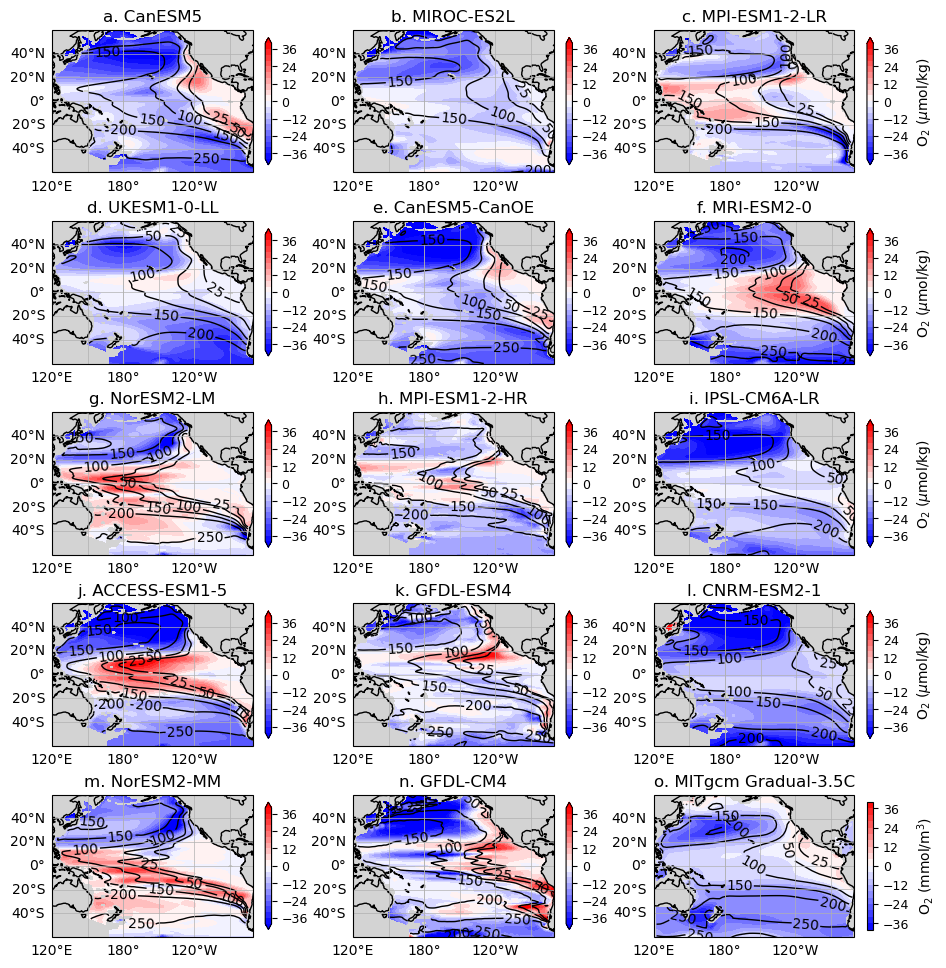

In [25]:
# Using the pre-processed dataset makes this fairly straightforward. 

proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(nrows = 5, ncols = 3, figsize = (11,12), subplot_kw={'projection': proj})
#axs = np.atleast_2d(axs)  # Ensure axs[0,0] indexing works if only one row

agemap = cmocean.cm.curl
agemap.set_bad(color='black')
cmapox = 'bwr'
#agemap.set_bad(color='black')
#fig, axs = plt.subplots(ncols=2 , nrows = 2,figsize=(12,8))

vm = 120
agelevels = [50, 100, 200, 400, 600, 800, 1200, 1600 ]
o2levels = [25,50,100,150,200,250] #[0.025,0.05, 0.1, 0.15, .2, .25 ]


#fig, axs = plt.subplots(ncols = 2, nrows =3, figsize=(13,12))
# latitudes are stuck to -60 and 60. But could give option for more detail. 
lons = np.arange(120, 290) # could also do full Pacific 
myX = lons - 50
#mydep = 2000 

k1=30
k2=46
mylevs = np.arange(k1,k2)

CMIPdrf= (np.array(CMIPdata.lev[(k1-1):k2].diff('lev'))+np.array(CMIPdata.lev[k1:(k2+1)].diff('lev')))/2
cmip_drf = xr.DataArray(
    CMIPdrf,
    dims=('lev'),
    coords={'lev': CMIPdata.lev[k1:k2]},
    name='cmip_drf')

sliceo2_sour = CMIPdata.o2.isel(time = 1, x= myX, lev= mylevs)
depo2_sour = sum(cmip_drf*sliceo2_sour)/sum(cmip_drf)
#sliceo2 = sliceo2_sour.mean('source_id')
#cmip_o2tr_pl = sum(cmip_drf*sliceo2)/sum(cmip_drf)

meano2_sour = CMIPdata.o2.isel(time = 0, x= myX, lev= mylevs)
mean_depo2_sour = sum(cmip_drf*meano2_sour)/sum(cmip_drf)
model_names = list(CMIPdata['source_id'].values)
lets = ['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o']

for i in range(5):
    for j in range(3):
        if (j==2 and i==4):
            continue
        else:
            CMIPtr = axs[i,j].contourf(CMIPdata.x.isel(x=myX), CMIPdata.y, 1.03*depo2_sour.isel(source_id = 3*i+j), vmin = -40, vmax = 40, levels = np.linspace(-40, 40,21), cmap = 'bwr',transform=ccrs.PlateCarree(), extend='both')
            CMIPo2mean = axs[i,j].contour(CMIPdata.x.isel(x=myX), CMIPdata.y, 1.03*mean_depo2_sour.isel(source_id = 3*i+j), colors= 'k', linewidths = 1, levels = o2levels,transform=ccrs.PlateCarree())
            CMIPo2mean.clabel()
            cbCMo = plt.colorbar(CMIPtr, ax = axs[i,j], shrink = 0.8)
            cbCMo.ax.tick_params(labelsize=9)
            if j==2:
                #cbCMo = plt.colorbar(CMIPtr, ax = axs[i,j], shrink = 0.8)
                cbCMo.set_label('O$_2$ (mmol/m$^3)')
            axs[i,j].set_title(str(lets[3*i+j])+'. '+model_names[3*i+j])
        axs[i,j].grid()
        axs[i,j].coastlines()
        axs[i,j].set_ylim([-60,60])
        gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
        gl.top_labels=False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
        axs[i,j].set_facecolor('lightgray')
        #axs[i,j].text(0.03, 0.94, lets[3*i+j], fontsize=13, transform=axs[i,j].transAxes, ha='left', va='top')


zran = range(8,13)
yran = range(64)
xran = np.arange(int(lons[0]*128/360)+1, int(lons[-1]*128/360)+1)

# Let's do a proper depth average systematically here 
# first for MITgcm
deps = O2con.drF.isel(Z=zran)*O2con.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpO2tr = O2tr.isel( XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
tmpO2c = O2contr.isel( XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
#tmpagetr = Agetr.isel( XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
#tmpagec = Agecontr.isel(XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 

PlO2tr = tmpO2tr.sum('Z')/deps.sum('Z')
PlO2c = tmpO2c.sum('Z')/deps.sum('Z')
#Plagetr = tmpagetr.sum('Z')/deps.sum('Z')
#Plagec = tmpagec.sum('Z')/deps.sum('Z')

tmpMito2 = O2conm.isel(XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
PlO2mean = tmpMito2.sum('Z')/deps.sum('Z')

MITo2tr= axs[4,2].contourf(O2con.XC.isel(XC=xran), O2con.YC, 1000*(PlO2tr-PlO2c) , cmap = 'bwr', vmin=-40, vmax = 40, levels = np.linspace(-40, 40,21), transform=ccrs.PlateCarree(), )
MITo2mean= axs[4,2].contour(O2con.XC.isel(XC=xran), O2con.YC, 1000*PlO2mean , colors = 'k', linewidths = 1, levels = o2levels, transform=ccrs.PlateCarree())
MITo2mean.clabel()
axs[4,2].set_title('o. MITgcm Gradual-3.5C')
#axs[0,1].set_ylim([-60,60])
#axs[0,1].set_xlim([lons[0],lons[-1]])
cbMITo = plt.colorbar(MITo2tr, ax = axs[4,2], shrink = 0.8)
cbMITo.set_label('O$_2$ (mmol/m$^3$)')
cbMITo.ax.tick_params(labelsize=9)
axs[4,2].set_xlim([-60,110])
axs[4,2].set_ylim([-60,60])

axs[4,2].grid()
axs[4,2].coastlines()
axs[4,2].set_ylim([-60,60])
gl = axs[4,2].gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels=False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
axs[4,2].set_facecolor('lightgray')
#axs[4,2].text(0.03, 0.94, lets[14], fontsize=13, transform=axs[4,2].transAxes, ha='left', va='top')

#plt.savefig('../eps_figures/supp_CMIPmaps_5-5.eps')

In [3]:
CMIPdata.source_id

<xarray.DataArray 'source_id' (source_id: 14)> Size: 728B
array(['CanESM5', 'MIROC-ES2L', 'MPI-ESM1-2-LR', 'UKESM1-0-LL',
       'CanESM5-CanOE', 'MRI-ESM2-0', 'NorESM2-LM', 'MPI-ESM1-2-HR',
       'IPSL-CM6A-LR', 'ACCESS-ESM1-5', 'GFDL-ESM4', 'CNRM-ESM2-1',
       'NorESM2-MM', 'GFDL-CM4'], dtype='<U13')
Coordinates:
  * source_id  (source_id) <U13 728B 'CanESM5' 'MIROC-ES2L' ... 'GFDL-CM4'

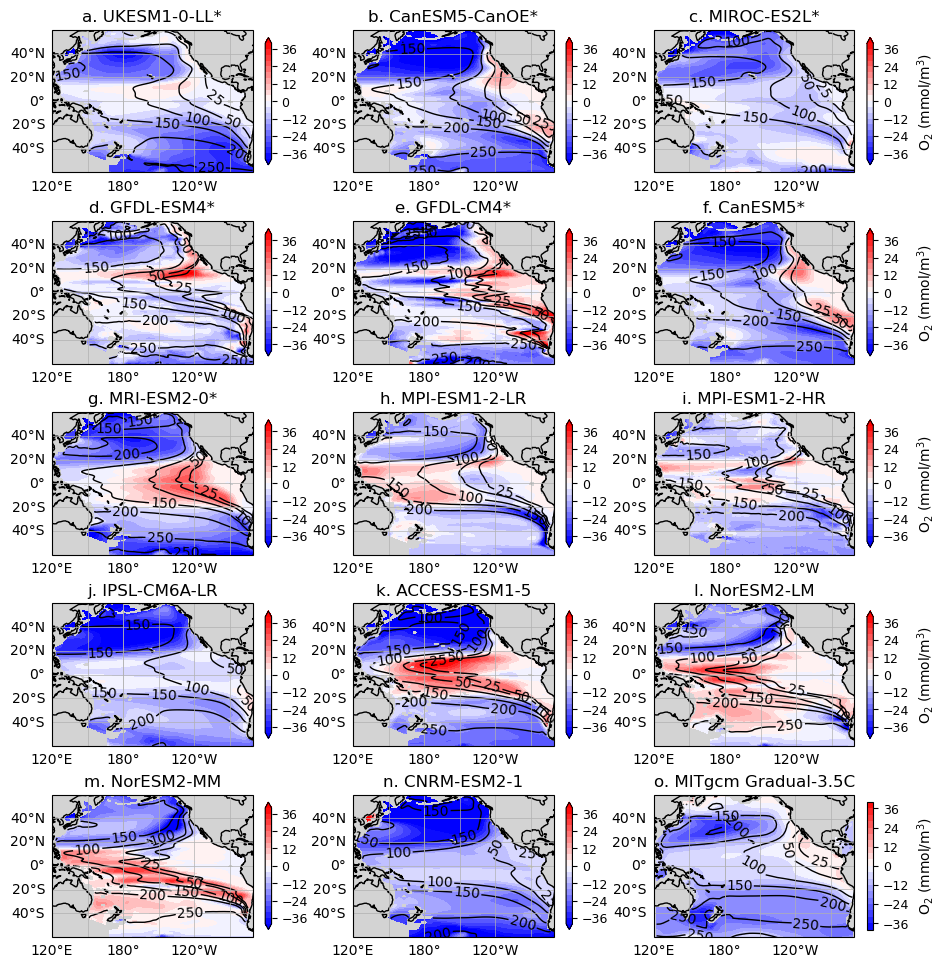

In [53]:
# Redoing the O2 to put just the better performing models as the first 7. 

#Using the pre-processed dataset makes this fairly straightforward. 
# 7 good models first, 
modlist = ['UKESM1-0-LL', 'CanESM5-CanOE', 'MIROC-ES2L','GFDL-ESM4','GFDL-CM4','CanESM5','MRI-ESM2-0', 'MPI-ESM1-2-LR', 'MPI-ESM1-2-HR', 'IPSL-CM6A-LR', 'ACCESS-ESM1-5', 'NorESM2-LM','NorESM2-MM','CNRM-ESM2-1',]

proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(nrows = 5, ncols = 3, figsize = (11,12), subplot_kw={'projection': proj})
#axs = np.atleast_2d(axs)  # Ensure axs[0,0] indexing works if only one row

agemap = cmocean.cm.curl
agemap.set_bad(color='black')
cmapox = 'bwr'
#agemap.set_bad(color='black')
#fig, axs = plt.subplots(ncols=2 , nrows = 2,figsize=(12,8))

vm = 120
agelevels = [50, 100, 200, 400, 600, 800, 1200, 1600 ]
o2levels = [25,50,100,150,200,250] #[0.025,0.05, 0.1, 0.15, .2, .25 ]


#fig, axs = plt.subplots(ncols = 2, nrows =3, figsize=(13,12))
# latitudes are stuck to -60 and 60. But could give option for more detail. 
lons = np.arange(120, 290) # could also do full Pacific 
myX = lons - 50
#mydep = 2000 

k1=30
k2=46
mylevs = np.arange(k1,k2)

CMIPdrf= (np.array(CMIPdata.lev[(k1-1):k2].diff('lev'))+np.array(CMIPdata.lev[k1:(k2+1)].diff('lev')))/2
cmip_drf = xr.DataArray(
    CMIPdrf,
    dims=('lev'),
    coords={'lev': CMIPdata.lev[k1:k2]},
    name='cmip_drf')

sliceo2_sour = CMIPdata.o2.isel(time = 1, x= myX, lev= mylevs)
depo2_sour = sum(cmip_drf*sliceo2_sour)/sum(cmip_drf)
#sliceo2 = sliceo2_sour.mean('source_id')
#cmip_o2tr_pl = sum(cmip_drf*sliceo2)/sum(cmip_drf)

meano2_sour = CMIPdata.o2.isel(time = 0, x= myX, lev= mylevs)
mean_depo2_sour = sum(cmip_drf*meano2_sour)/sum(cmip_drf)
model_names = list(CMIPdata['source_id'].values)
lets = ['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o']

for i in range(5):
    for j in range(3):
        if (j==2 and i==4):
            continue
        else:
            ind = 3*i+j
            CMIPtr = axs[i,j].contourf(CMIPdata.x.isel(x=myX), CMIPdata.y, 1.03*depo2_sour.sel(source_id = modlist[ind] ), vmin = -40, vmax = 40, levels = np.linspace(-40, 40,21), cmap = 'bwr',transform=ccrs.PlateCarree(), extend='both')
            CMIPo2mean = axs[i,j].contour(CMIPdata.x.isel(x=myX), CMIPdata.y, 1.03*mean_depo2_sour.sel(source_id = modlist[ind]), colors= 'k', linewidths = 1, levels = o2levels,transform=ccrs.PlateCarree())
            CMIPo2mean.clabel()
            cbCMo = plt.colorbar(CMIPtr, ax = axs[i,j], shrink = 0.8)
            cbCMo.ax.tick_params(labelsize=9)
            if j==2:
                #cbCMo = plt.colorbar(CMIPtr, ax = axs[i,j], shrink = 0.8)
                cbCMo.set_label('O$_2$ (mmol/m$^3$)')
            aststr = ''
            if ind <7:
                aststr = '*'
            axs[i,j].set_title(str(lets[ind])+'. '+modlist[ind] + aststr)
        axs[i,j].grid()
        axs[i,j].coastlines()
        axs[i,j].set_ylim([-60,60])
        gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
        gl.top_labels=False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
        axs[i,j].set_facecolor('lightgray')
        #axs[i,j].text(0.03, 0.94, lets[3*i+j], fontsize=13, transform=axs[i,j].transAxes, ha='left', va='top')


zran = range(8,13)
yran = range(64)
xran = np.arange(int(lons[0]*128/360)+1, int(lons[-1]*128/360)+1)

# Let's do a proper depth average systematically here 
# first for MITgcm
deps = O2conm.drF.isel(Z=zran)*O2con.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpO2tr = O2tr.isel( XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
tmpO2c = O2contr.isel( XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
#tmpagetr = Agetr.isel( XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 
#tmpagec = Agecontr.isel(XC = xran, YC = yran, Z= zran)*DIC50.drF.isel(Z=zran) 

PlO2tr = tmpO2tr.sum('Z')/deps.sum('Z')
PlO2c = tmpO2c.sum('Z')/deps.sum('Z')
#Plagetr = tmpagetr.sum('Z')/deps.sum('Z')
#Plagec = tmpagec.sum('Z')/deps.sum('Z')

tmpMito2 = O2conm.isel(XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
PlO2mean = tmpMito2.sum('Z')/deps.sum('Z')

MITo2tr= axs[4,2].contourf(O2con.XC.isel(XC=xran), O2con.YC, 1000*(PlO2tr-PlO2c) , cmap = 'bwr', vmin=-40, vmax = 40, levels = np.linspace(-40, 40,21), transform=ccrs.PlateCarree(), )
MITo2mean= axs[4,2].contour(O2con.XC.isel(XC=xran), O2con.YC, 1000*PlO2mean , colors = 'k', linewidths = 1, levels = o2levels, transform=ccrs.PlateCarree())
MITo2mean.clabel()
axs[4,2].set_title('o. MITgcm Gradual-3.5C')
#axs[0,1].set_ylim([-60,60])
#axs[0,1].set_xlim([lons[0],lons[-1]])
cbMITo = plt.colorbar(MITo2tr, ax = axs[4,2], shrink = 0.8)
cbMITo.set_label('O$_2$ (mmol/m$^3$)')
cbMITo.ax.tick_params(labelsize=9)
axs[4,2].set_xlim([-60,110])
axs[4,2].set_ylim([-60,60])

axs[4,2].grid()
axs[4,2].coastlines()
axs[4,2].set_ylim([-60,60])
gl = axs[4,2].gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels=False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
axs[4,2].set_facecolor('lightgray')
#axs[4,2].text(0.03, 0.94, lets[14], fontsize=13, transform=axs[4,2].transAxes, ha='left', va='top')

#plt.savefig('../eps_figures/supp_CMIPo2group_5-17.eps', bbox_inches="tight")

In [80]:
## Same thing for age. 

CMIPdata.source_id

agemods = ['CanESM5', 'MIROC-ES2L', 'MPI-ESM1-2-LR', 
       'CanESM5-CanOE',  'NorESM2-LM', 
       'IPSL-CM6A-LR', 'ACCESS-ESM1-5', 'GFDL-ESM4', 
       'NorESM2-MM', 'GFDL-CM4']

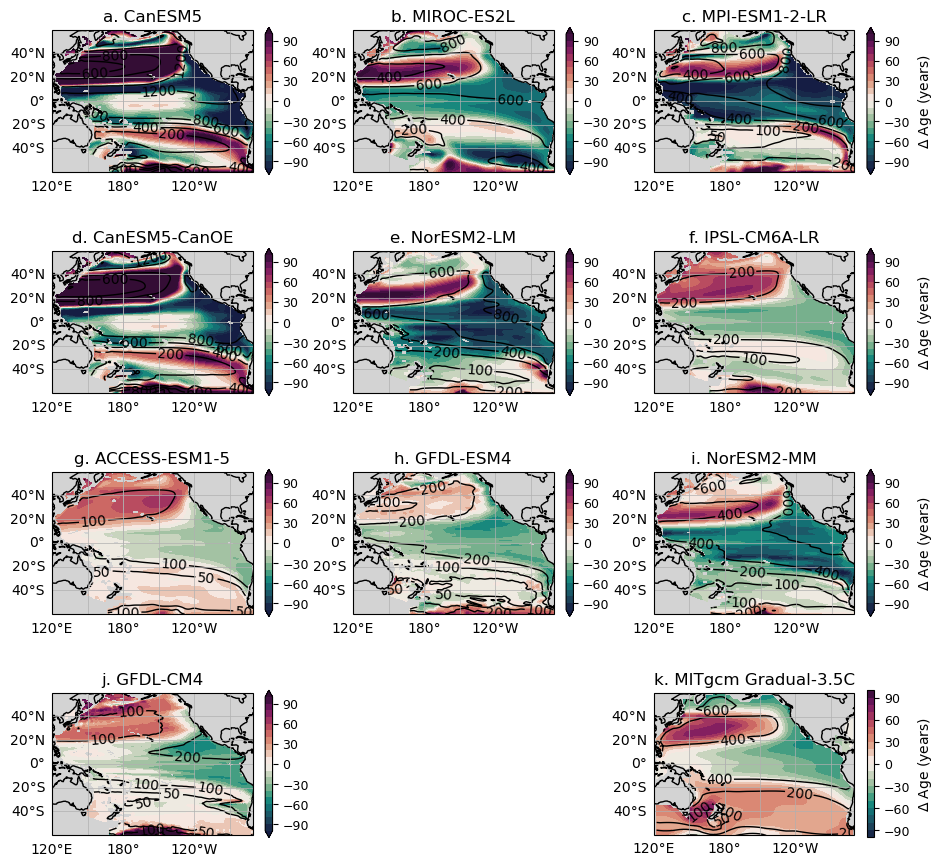

In [23]:
# actually this is very fast to write thanks to Julius's pre-processing ...

# doing the same thing for age

proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(nrows = 4, ncols = 3, figsize = (11,11), subplot_kw={'projection': proj})
#axs = np.atleast_2d(axs)  # Ensure axs[0,0] indexing works if only one row

agemap = cmocean.cm.curl
agemap.set_bad(color='black')
cmapox = 'bwr'
#agemap.set_bad(color='black')
#fig, axs = plt.subplots(ncols=2 , nrows = 2,figsize=(12,8))

vm = 120
agelevels = [50, 100, 200, 400, 600, 800, 1200, 1600 ]
o2levels = [25,50,100,150,200,250] #[0.025,0.05, 0.1, 0.15, .2, .25 ]


#fig, axs = plt.subplots(ncols = 2, nrows =3, figsize=(13,12))
# latitudes are stuck to -60 and 60. But could give option for more detail. 
lons = np.arange(120, 290) # could also do full Pacific 
myX = lons - 50
#mydep = 2000 

k1=30
k2=46
mylevs = np.arange(k1,k2)

CMIPdrf= (np.array(CMIPdata.lev[(k1-1):k2].diff('lev'))+np.array(CMIPdata.lev[k1:(k2+1)].diff('lev')))/2
cmip_drf = xr.DataArray(
    CMIPdrf,
    dims=('lev'),
    coords={'lev': CMIPdata.lev[k1:k2]},
    name='cmip_drf')

sliceage_sour = CMIPdata.agessc.isel(time = 1, x= myX, lev= mylevs)
depage_sour = sum(cmip_drf*sliceage_sour)/sum(cmip_drf)
#sliceo2 = sliceo2_sour.mean('source_id')
#cmip_o2tr_pl = sum(cmip_drf*sliceo2)/sum(cmip_drf)

meanage_sour = CMIPdata.agessc.isel(time = 0, x= myX, lev= mylevs)
mean_depage_sour = sum(cmip_drf*meanage_sour)/sum(cmip_drf)

agemods = ['CanESM5', 'MIROC-ES2L', 'MPI-ESM1-2-LR', 
       'CanESM5-CanOE',  'NorESM2-LM', 
       'IPSL-CM6A-LR', 'ACCESS-ESM1-5', 'GFDL-ESM4', 
       'NorESM2-MM', 'GFDL-CM4']
#model_names = list(CMIPdata['source_id'].values)
lets = ['a','b','c','d','e','f','g','h','i','j','k','l','m','n','o']



for i in range(4):
    for j in range(3):
        if (j>0 and i==3):
            continue
        else:
            mod = agemods[3*i+j]
            CMIPtr = axs[i,j].contourf(CMIPdata.x.isel(x=myX), CMIPdata.y, depage_sour.sel(source_id = mod), vmin = -100, vmax = 100, levels = np.linspace(-100, 100,21), cmap = agemap,transform=ccrs.PlateCarree(), extend='both')
            CMIPagemean = axs[i,j].contour(CMIPdata.x.isel(x=myX), CMIPdata.y, mean_depage_sour.sel(source_id = mod), colors= 'k', linewidths = 1, levels = agelevels,transform=ccrs.PlateCarree())
            CMIPagemean.clabel()
            cbCMo = plt.colorbar(CMIPtr, ax = axs[i,j], shrink = 0.8)
            cbCMo.ax.tick_params(labelsize=9)
            if j==2:
                #cbCMo = plt.colorbar(CMIPtr, ax = axs[i,j], shrink = 0.8)
                cbCMo.set_label('$\Delta$ Age (years)')
            axs[i,j].set_title(str(lets[3*i+j])+'. '+mod)
        axs[i,j].grid()
        axs[i,j].coastlines()
        axs[i,j].set_ylim([-60,60])
        gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
        gl.top_labels=False
        gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
        axs[i,j].set_facecolor('lightgray')
        #axs[i,j].text(0.03, 0.94, lets[3*i+j], fontsize=13, transform=axs[i,j].transAxes, ha='left', va='top')


zran = range(8,13)
yran = range(64)
xran = np.arange(int(lons[0]*128/360)+1, int(lons[-1]*128/360)+1)

# Let's do a proper depth average systematically here 
# first for MITgcm
deps = O2con.drF.isel(Z=zran)*O2con.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpAgetr = Agetr.isel( XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
tmpAgec = Agecontr.isel( XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 

PlAgetr = tmpAgetr.sum('Z')/deps.sum('Z')
PlAgec = tmpAgec.sum('Z')/deps.sum('Z')


tmpMitAge = Ageconm.isel(XC = xran, YC = yran, Z= zran)*O2con.drF.isel(Z=zran) 
PlAgemean = tmpMitAge.sum('Z')/deps.sum('Z')

MITo2tr= axs[3,2].contourf(O2con.XC.isel(XC=xran), O2con.YC, (PlAgetr-PlAgec) , cmap = agemap, vmin=-100, vmax = 100, levels = np.linspace(-100, 100,21), transform=ccrs.PlateCarree(), )
MITo2mean= axs[3,2].contour(O2con.XC.isel(XC=xran), O2con.YC, PlAgemean , colors = 'k', linewidths = 1, levels = agelevels, transform=ccrs.PlateCarree())
MITo2mean.clabel()
axs[3,2].set_title('k. MITgcm Gradual-3.5C')
#axs[0,1].set_ylim([-60,60])
#axs[0,1].set_xlim([lons[0],lons[-1]])
cbMITo = plt.colorbar(MITo2tr, ax = axs[3,2], shrink = 0.8)
cbMITo.set_label('$\Delta$ Age (years)')
cbMITo.ax.tick_params(labelsize=9)
axs[3,2].set_xlim([-60,110])
axs[3,2].set_ylim([-60,60])
axs[3,2].grid()
axs[3,2].coastlines()
axs[3,2].set_ylim([-60,60])
gl = axs[3,2].gridlines(draw_labels=True, linewidth=0.5)
gl.top_labels=False
gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
axs[3,2].set_facecolor('lightgray')
#axs[4,2].text(0.03, 0.94, lets[14], fontsize=13, transform=axs[4,2].transAxes, ha='left', va='top')
axs[3,1].remove()
#plt.savefig('../eps_figures/supp_CMIPage_5-5.eps', bbox_inches="tight")